In [1]:
%cd /app

/app


In [2]:
import argparse
import os
import sys

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import torch
torch.multiprocessing.set_start_method('spawn')

import jax
from lob.encoding import Vocab, Message_Tokenizer

from lob import inference_no_errcorr as inference
from lob.init_train import init_train_state, load_checkpoint, load_metadata, load_args_from_checkpoint

from lob import inference_no_errcorr as inference
import lob.encoding as encoding
import preproc as preproc

import jax.numpy as jnp
import numpy as np

from pathlib import Path
import os

import pandas as pd

import pandas as pd
import plotly.graph_objs as go
import yaml

from filtration_utils import summary_table, build_zero_padded_series, plot_midprice_series_with_insertions, prepare_volatility_filtered_series, plot_midprice_series_with_mean_std

2025-12-10 17:07:39.788799: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [3]:
experiment_name = 'b0_b7_aggresive/exp_1_20251005_220723_gen_buy_75_b0_b7'  #       exp_85_20250823_020427_1024
sample_day_map_name ='batches_equal_sample_day_map'
sample_day_map = pd.read_csv(f'/app/{sample_day_map_name}.csv')


CONFIG_PATH = f"/app/data_saved/{experiment_name}/used_config.yaml"

# Load YAML config
with open(CONFIG_PATH, 'r') as f:
    config = yaml.safe_load(f)

# Extract values
num_insertions      = config["num_insertions"]
num_coolings        = config["num_coolings"]
midprice_step_size  = config["midprice_step_size"]
hist_msgs           = config["n_messages"]
n_gen_msgs          = config["n_gen_msgs"]
Direction           = config["DIRECTION_i"]

print(f"Aggressive {'buy' if Direction == 0 else 'sell'}\n")
print(f'num_insertions: {num_insertions}')
print(f'num_coolings: {num_coolings}')
print(f'midprice_step_size: {midprice_step_size}')
print(f'hist_msgs: {hist_msgs}')
print(f'n_gen_msgs: {n_gen_msgs}')

Aggressive buy

num_insertions: 10
num_coolings: 50
midprice_step_size: 1
hist_msgs: 500
n_gen_msgs: 50


In [4]:
order_volume = config["order_volume"]
order_volume_ratio = config["order_volume_ratio"]
use_relative_volume = config["use_relative_volume"]

print(f'use_relative_volume: {use_relative_volume}')
print(f'order_volume: {order_volume}')
print(f'order_volume_ratio: {order_volume_ratio}')

# use_sample_file = config["use_sample_file"]
# sample_file_path = config["sample_file_path"]
# start_batch = config["start_batch"]
# end_batch = config["end_batch"]

# print(f'\nuse_sample_file: {use_sample_file}')
# print(f'sample_file_path: {sample_file_path}')
# print(f'start_batch: {start_batch}')
# print(f'end_batch: {end_batch}')

use_relative_volume: False
order_volume: 75
order_volume_ratio: 1.0


In [5]:
hist_steps = hist_msgs // midprice_step_size       # 500
gen_steps = n_gen_msgs // midprice_step_size     # 50
gen_block = gen_steps + 1                        # 51

merged = summary_table(experiment_name)
x, all_series = build_zero_padded_series(hist_msgs, n_gen_msgs, midprice_step_size, merged)

# merged = merged[:10]

print(merged)

[summary_table] Loaded file: /app/data_saved/b0_b7_aggresive/exp_1_20251005_220723_gen_buy_75_b0_b7/mid_price/mid_price_batch_[1296, 2287, 1962, 1123, 4694, 5808, 2664, 5200, 2158, 2131, 3373, 5815, 5640, 1579, 3652, 373]_iter_1.npy
[summary_table]  arr.shape: (551, 16) arr.ndim: 2
[summary_table]  ids (len= 16 ): [1296, 2287, 1962, 1123, 4694, 5808, 2664, 5200, 2158, 2131, 3373, 5815, 5640, 1579, 3652, 373]
[summary_table]  expected batch columns: 16
[summary_table]   accessing col=0 for sample_id=1296
[summary_table]   accessing col=1 for sample_id=2287
[summary_table]   accessing col=2 for sample_id=1962
[summary_table]   accessing col=3 for sample_id=1123
[summary_table]   accessing col=4 for sample_id=4694
[summary_table]   accessing col=5 for sample_id=5808
[summary_table]   accessing col=6 for sample_id=2664
[summary_table]   accessing col=7 for sample_id=5200
[summary_table]   accessing col=8 for sample_id=2158
[summary_table]   accessing col=9 for sample_id=2131
[summary_table

In [6]:
import plotly.graph_objs as go

# Отрисовать все
fig = go.Figure()
for i in range(all_series.shape[0]):
    fig.add_trace(go.Scatter(
        y=all_series[i],
        mode='lines',
        name=f"Series {i}"
    ))

fig.update_layout(
    title="Все серии в all_series",
    xaxis_title="Time step",
    yaxis_title="Value"
)
fig.show()

In [7]:
x

array([   1,    2,    3, ..., 3508, 3509, 3510])

# ----------------------------------------------------

# OREDER-PLAYER

In [8]:
import os, glob, re
import numpy as np
import pandas as pd

def build_and_merge(folder, batch_prefix, inp_prefix):
    # STEP 1: load every .npy (shape (batch_size, time, feat)) into a DataFrame
    files   = glob.glob(os.path.join(folder, "*.npy"))
    rx_iter = re.compile(rf"{re.escape(batch_prefix)}_\[(.+)\]_iter_(\d+)\.npy$")
    rx_inp  = re.compile(rf"{re.escape(inp_prefix)}_\[(.+)\]\.npy$")
    rec = []
    for f in files:
        nm = os.path.basename(f)
        m  = rx_iter.match(nm)
        if m:
            rng, itr = m.group(1).replace(" ", ""), int(m.group(2))
        else:
            m2 = rx_inp.match(nm)
            if not m2:
                continue
            rng, itr = m2.group(1).replace(" ", ""), 0

        batch = np.load(f)  # shape (batch_size, time, features)
        print(f"Loaded {nm} with shape {batch.shape}")

        rec.append({"range": rng, "iteration": itr, "batch": batch})
    df = pd.DataFrame(rec).sort_values(["range","iteration"]).reset_index(drop=True)

    # STEP 2: parse the comma‐separated list of IDs into Python lists
    df["ids"] = df["range"].str.split(",").apply(lambda L: [int(x) for x in L])

    # explode each batch into one row per sample, с учётом slicing
    rows = []
    for _, r in df.iterrows():
        for idx, sample_id in enumerate(r["ids"]):
            single = r["batch"][idx]   # shape (time, features)

            # ====== здесь происходит нужный slice ======
            if r["iteration"] > 0:
                n_keep = 51 if r["iteration"] <= num_insertions else 50
                single = single[-n_keep:, :]
            # ============================================

            rows.append({
                "id":        sample_id,
                "iteration": r["iteration"],
                "data":      single
            })

    df_sorted = pd.DataFrame(rows).sort_values(["id","iteration"]).reset_index(drop=True)

    merged = []
    for id_val, grp in df_sorted.groupby("id", sort=True):
        arrs = [row.data for _, row in grp.iterrows()]
        big  = np.concatenate(arrs, axis=0)
        merged.append({"id": id_val, "merged_data": big})
    merged_df = pd.DataFrame(merged).sort_values("id").reset_index(drop=True)

    return df, df_sorted, merged_df

import os
import pickle

save_folder = f"/app/data_saved/{experiment_name}"
os.makedirs(save_folder, exist_ok=True)

b_dict_path = f"{save_folder}/unfiltered_b_dict.pkl"
m_dict_path = f"{save_folder}/unfiltered_m_dict.pkl"

if os.path.exists(b_dict_path) and os.path.exists(m_dict_path):
    print(f"Loading unfiltered_b_dict and unfiltered_m_dict from {save_folder}")
    with open(b_dict_path, "rb") as f:
        b_dict = pickle.load(f)
    with open(m_dict_path, "rb") as f:
        m_dict = pickle.load(f)
else:
    b_folder      = f"/app/data_saved/{experiment_name}/b_seq_gen_doubled"
    b_batch_pref  = "b_seq_gen_doubled_batch"
    b_inp_pref    = "b_seq_inp"

    m_folder      = f"/app/data_saved/{experiment_name}/msgs_decoded_doubled"
    m_batch_pref  = "msgs_decoded_doubled_batch"
    m_inp_pref    = "m_seq_raw_inp"

    _, b_sorted, b_merged = build_and_merge(b_folder, b_batch_pref, b_inp_pref)
    _, m_sorted, m_merged = build_and_merge(m_folder, m_batch_pref, m_inp_pref)

    b_dict = { int(r.id): np.array(r.merged_data) for _, r in b_merged.iterrows() }
    m_dict = { int(r.id): np.array(r.merged_data) for _, r in m_merged.iterrows() }

    for d in (b_dict, m_dict):
        for key, arr in d.items():
            zero = np.zeros((1, arr.shape[1]), dtype=arr.dtype)
            d[key] = np.vstack([zero, arr])

    with open(b_dict_path, "wb") as f:
        pickle.dump(b_dict, f)
    with open(m_dict_path, "wb") as f:
        pickle.dump(m_dict, f)
    print(f"Saved unfiltered_b_dict and unfiltered_m_dict to {save_folder}")


Loading unfiltered_b_dict and unfiltered_m_dict from /app/data_saved/b0_b7_aggresive/exp_1_20251005_220723_gen_buy_75_b0_b7


In [9]:
# # Save the dictionaries and merged data to the experiment folder
# import pickle
# import os

# save_folder = f"/app/data_saved/{experiment_name}"
# os.makedirs(save_folder, exist_ok=True)

# # Save b_dict
# with open(f"{save_folder}/b_dict.pkl", "wb") as f:
#     pickle.dump(b_dict, f)

# # Save m_dict
# with open(f"{save_folder}/m_dict.pkl", "wb") as f:
#     pickle.dump(m_dict, f)

# # Save merged dataframes
# with open(f"{save_folder}/b_merged.pkl", "wb") as f:
#     pickle.dump(b_merged, f)

# with open(f"{save_folder}/m_merged.pkl", "wb") as f:
#     pickle.dump(m_merged, f)

# print(f"Saved b_dict, m_dict, b_merged, and m_merged to {save_folder}")


In [10]:
import numpy as np
import pandas as pd
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- helpers ---------------------------------------------------------------

def split_l2_vector(vec: np.ndarray,
                    ask_before_bid: bool = True,
                    odd_policy: str = "drop_center"):
    """
    Split a 1D L2 vector into (ask_vec, bid_vec).

    - If len(vec) is even: split into two equal halves.
    - If len(vec) is odd and odd_policy == "drop_center":
        drop the center column (index len//2) and split the remainder evenly.
    - odd_policy can be "drop_center", "drop_last", or "error".
    Returns (ask_vec, bid_vec, dropped_index_or_None)
    """
    n = int(vec.shape[0])

    if n % 2 == 0:
        k = n // 2
        if ask_before_bid:
            ask, bid = vec[:k], vec[k:]
        else:
            bid, ask = vec[:k], vec[k:]
        return ask, bid, None

    # odd length:
    if odd_policy == "drop_center":
        mid = n // 2
        # build a new vector without the center element
        if ask_before_bid:
            ask = vec[:mid]
            bid = vec[mid+1:]
        else:
            bid = vec[:mid]
            ask = vec[mid+1:]
        return ask, bid, mid

    elif odd_policy == "drop_last":
        vec2 = vec[:-1]
        return split_l2_vector(vec2, ask_before_bid=ask_before_bid, odd_policy="drop_center")

    elif odd_policy == "error":
        raise ValueError(f"Odd L2 width ({n}); cannot split evenly without a policy.")

    else:
        raise ValueError(f"Unknown odd_policy={odd_policy!r}")


def compute_queued_volumes_over_time(book_array: np.ndarray,
                                     l2_start: int = 240,
                                     l2_end: int = 263,
                                     ask_before_bid: bool = True,
                                     odd_policy: str = "drop_center",
                                     use_abs: bool = True):
    """
    For each time t, sum queued volume on ASK and BID from the L2 slice [l2_start:l2_end).
    Handles odd width by the given odd_policy (default: drop the center column).
    """
    T = book_array.shape[0]
    bid_vol = np.empty(T, dtype=float)
    ask_vol = np.empty(T, dtype=float)

    for t in range(T):
        vec = book_array[t, l2_start:l2_end].astype(float)
        ask_vec, bid_vec, _ = split_l2_vector(vec, ask_before_bid=ask_before_bid, odd_policy=odd_policy)
        if use_abs:
            bid_vol[t] = float(np.sum(np.abs(bid_vec)))
            ask_vol[t] = float(np.sum(np.abs(ask_vec)))
        else:
            bid_vol[t] = float(np.sum(bid_vec))
            ask_vol[t] = float(np.sum(ask_vec))

    total = bid_vol + ask_vol
    return bid_vol, ask_vol, total


# --- main widget -----------------------------------------------------------

def interactive_lob_plot(b_seq_inp, msg_seq_raw,
                         l2_start: int = 240, l2_end: int = 263,
                         ask_before_bid: bool = True,
                         odd_policy: str = "drop_center",
                         use_abs: bool = True):
    """
    Extends your original function:
    - keeps the two book-state panels
    - computes queued volumes (Bid/Ask/Total) over time from the same L2 slice
    - shows a live volume chart and prints volumes at current t
    """

    # allow DataFrame or dict
    if isinstance(b_seq_inp, pd.DataFrame):
        b_seq_inp = {int(r.id): np.array(r.merged_data) for _, r in b_seq_inp.iterrows()}
    if isinstance(msg_seq_raw, pd.DataFrame):
        msg_seq_raw = {int(r.id): np.array(r.merged_data) for _, r in msg_seq_raw.iterrows()}

    # controls
    id_dd       = widgets.Dropdown(options=sorted(b_seq_inp.keys()), description="Sample ID:")
    time_slider = widgets.IntSlider(min=1, max=1, step=1, description="t:")
    btn_prev    = widgets.Button(description="←", layout=widgets.Layout(width="50px"))
    btn_next    = widgets.Button(description="→", layout=widgets.Layout(width="50px"))
    msg_box     = widgets.HTML()
    vol_box     = widgets.HTML()  # will show numeric volumes at t

    # --- Figure A: two book panels
    figA = make_subplots(rows=1, cols=2, subplot_titles=["Book state t–1", "Book state t"])
    figA.add_trace(go.Bar(x=[], y=[]), row=1, col=1)
    figA.add_trace(go.Bar(x=[], y=[]), row=1, col=2)
    figA.update_layout(width=900, height=380, showlegend=False, template='plotly_white', margin=dict(l=30,r=30,t=50,b=30))
    figA_widget = go.FigureWidget(figA)

    # --- Figure B: volumes over time
    figB = go.FigureWidget(
        go.Figure(layout=go.Layout(
            width=900, height=280, template='plotly_white', margin=dict(l=30,r=30,t=30,b=30)
        ))
    )
    # add empty traces for bid/ask/total
    figB.add_scatter(x=[], y=[], mode='lines', name='Ask queued volume')
    figB.add_scatter(x=[], y=[], mode='lines', name='Bid queued volume')
    figB.add_scatter(x=[], y=[], mode='lines', name='Total queued volume')
    # vertical cursor at t
    figB.add_shape(type="line", x0=0, x1=0, y0=0, y1=1, xref="x", yref="paper",
                   line=dict(color="gray", width=1, dash="dash"))

    # internal cache per sample_id to avoid recomputing every slider move
    _vol_cache = {}

    def update_slider_range(*_):
        arr = b_seq_inp[id_dd.value]
        time_slider.min = 1
        time_slider.max = arr.shape[0] - 1
        time_slider.value = 1

        # (re)compute volumes for this sample once
        if id_dd.value not in _vol_cache:
            bid_v, ask_v, tot_v = compute_queued_volumes_over_time(
                arr, l2_start=l2_start, l2_end=l2_end,
                ask_before_bid=ask_before_bid, odd_policy=odd_policy, use_abs=use_abs
            )
            _vol_cache[id_dd.value] = (bid_v, ask_v, tot_v)

        # refresh the volume chart lines for the new sample
        bid_v, ask_v, tot_v = _vol_cache[id_dd.value]
        T = len(bid_v)
        xs = np.arange(T)

        with figB.batch_update():
            figB.data[0].x = xs; figB.data[0].y = bid_v
            figB.data[1].x = xs; figB.data[1].y = ask_v
            figB.data[2].x = xs; figB.data[2].y = tot_v
            # reset vertical cursor to current t
            figB.layout.shapes[0].x0 = time_slider.value
            figB.layout.shapes[0].x1 = time_slider.value
            figB.update_xaxes(title="Time")
            figB.update_yaxes(title="Queued volume (sum over L2)")

    def update_plot(*_):
        sid = id_dd.value
        t   = time_slider.value
        arr = b_seq_inp[sid]
        msgs= msg_seq_raw[sid]

        # slice the same L2 window you visualize
        # NOTE: this window is odd (263-240=23). We handle it with odd_policy="drop_center" by default.
        s0 = arr[t-1, l2_start:l2_end]
        s1 = arr[t,   l2_start:l2_end]

        # difference coloring as you had
        diff = np.abs(s1) - np.abs(s0)
        x = np.arange(len(s0)) - len(s0)//2
        colors = ['orange' if abs(d)<1e-8 else ('red' if d>0 else 'blue') for d in diff]

        # book panels
        with figA_widget.batch_update():
            figA_widget.data = []  # clear
            figA_widget.add_bar(x=x, y=s0, row=1, col=1, marker_color='orange')
            figA_widget.add_bar(x=x, y=s1, row=1, col=2, marker_color=colors)
            figA_widget.layout.annotations[0].text = f"Book state {t-1}"
            figA_widget.layout.annotations[1].text = f"Book state {t}"

        # message info
        m = msgs[t].astype(int)
        # fields: [0]=timestamp, [1]=etype, [2]=dir, [3]=abspr, [4]=relpr, [5]=size, …
        et, dr, abspr, relpr, sz = m[1], m[2], m[3], m[4], m[5]
        et_map = {1:"Limit", 2:"PartialCancel", 3:"Delete", 4:"Execution"}
        dr_map = {1:"Buy", 0:"Sell"}
        info = (
            f"{et_map.get(et,'?')} • {dr_map.get(dr,'?')} • abs={abspr} • rel={relpr} • size={sz}"
        )
        msg_box.value = f"<b>{info}</b><br>raw: {m.tolist()}"

        # volumes at t (from cache)
        bid_v, ask_v, tot_v = _vol_cache[sid]
        bv, av, tv = bid_v[t], ask_v[t], tot_v[t]
        vol_box.value = f"<b>Queued volume @ t={t}:</b>  Bid={bv:.0f} • Ask={av:.0f} • Total={tv:.0f}"

        # move the vertical cursor on the volume chart
        with figB.batch_update():
            figB.layout.shapes[0].x0 = t
            figB.layout.shapes[0].x1 = t

    def on_prev(_):
        if time_slider.value > time_slider.min:
            time_slider.value -= 1

    def on_next(_):
        if time_slider.value < time_slider.max:
            time_slider.value += 1

    # wire up events
    id_dd.observe(lambda _: update_slider_range(), names='value')
    time_slider.observe(lambda _: update_plot(), names='value')
    btn_prev.on_click(on_prev)
    btn_next.on_click(on_next)

    # initial draw
    update_slider_range()
    update_plot()

    # layout
    controls = widgets.HBox([id_dd, btn_prev, btn_next, time_slider])
    display(controls)
    display(figA_widget)
    display(figB)
    display(vol_box, msg_box)


# ---- run it (using your objects) ----
interactive_lob_plot(b_dict, m_dict,
                     l2_start=210, l2_end=293,     # <- your current visualization window
                     ask_before_bid=True,          # <- flip to False if your storage is BID|ASK
                     odd_policy="drop_center",     # <- drop the center column when width is odd
                     use_abs=True)                 # <- abs-sum avoids sign cancellation

FigureWidget({
    'data': [{'marker': {'color': 'orange'},
              'type': 'bar',
              'uid': 'ebcb106c-957b-42c6-b812-72b1ca8030cf',
              'x': {'bdata': ('19jZ2tvc3d7f4OHi4+Tl5ufo6err7O' ... 'QVFhcYGRobHB0eHyAhIiMkJSYnKCk='),
                    'dtype': 'i1'},
              'xaxis': 'x',
              'y': {'bdata': ('AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA' ... 'AAAAAAAAAAAAAAAAAAAAAAAAAAAAA='),
                    'dtype': 'f4'},
              'yaxis': 'y'},
             {'marker': {'color': [orange, orange, orange, orange, orange, orange,
                                   orange, orange, orange, orange, orange, orange,
                                   orange, orange, orange, orange, orange, orange,
                                   orange, orange, orange, orange, orange, orange,
                                   orange, orange, orange, orange, orange, orange,
                                   red, red, red, red, red, red, red, red, red,
                      

FigureWidget({
    'data': [{'mode': 'lines',
              'name': 'Ask queued volume',
              'type': 'scatter',
              'uid': '794318a7-6f52-46a3-aea9-ebb3d988465e',
              'x': {'bdata': ('AAABAAIAAwAEAAUABgAHAAgACQAKAA' ... 'wNrQ2uDa8NsA2xDbINsw20DbUNtg0='),
                    'dtype': 'i2'},
              'y': {'bdata': ('AAAAAAAAAAAAAIDZoUUEQAAAgNmhRQ' ... 'hTCtfzPwAA+FMK1/M/AAD4UwrX8z8='),
                    'dtype': 'f8'}},
             {'mode': 'lines',
              'name': 'Bid queued volume',
              'type': 'scatter',
              'uid': '3a6326f2-0f97-4a8c-a9ef-c141ff7291e9',
              'x': {'bdata': ('AAABAAIAAwAEAAUABgAHAAgACQAKAA' ... 'wNrQ2uDa8NsA2xDbINsw20DbUNtg0='),
                    'dtype': 'i2'},
              'y': {'bdata': ('AAAAAAAAAAAAAABDXI8MQAAAAJdqvA' ... 'DOn7o0QAAA4FbhujRAAADgBim8NEA='),
                    'dtype': 'f8'}},
             {'mode': 'lines',
              'name': 'Total queued volume',
              'type

HTML(value='<b>Queued volume @ t=1:</b>  Bid=3 • Ask=4 • Total=6')

HTML(value='<b>Delete • Buy • abs=864600 • rel=-2 • size=22</b><br>raw: [44287878, 3, 1, 864600, -2, 22, 0, 28…

In [11]:
import os
import pickle
import numpy as np
import pandas as pd

# Paths for filtered files
filtered_b_dict_path = f'/app/data_saved/{experiment_name}/filtered_b_dict.pkl'
filtered_m_dict_path = f'/app/data_saved/{experiment_name}/filtered_m_dict.pkl'
filtered_merged_path = f'/app/data_saved/{experiment_name}/filtered_merged.pkl'
filtered_samples_csv = f'/app/data_saved/{experiment_name}/samples_after_book_filtration.csv'

# Check if all filtered files exist
b_dict_exists = os.path.exists(filtered_b_dict_path)
m_dict_exists = os.path.exists(filtered_m_dict_path)
merged_exists = os.path.exists(filtered_merged_path)
samples_csv_exists = os.path.exists(filtered_samples_csv)

if b_dict_exists and m_dict_exists and samples_csv_exists:
    # --- Just import them ---
    with open(filtered_b_dict_path, 'rb') as f:
        b_dict = pickle.load(f)
    with open(filtered_m_dict_path, 'rb') as f:
        m_dict = pickle.load(f)
    if merged_exists:
        merged = pd.read_pickle(filtered_merged_path)
    else:
        merged = None
    samples_df = pd.read_csv(filtered_samples_csv)
    sample_ids = sorted(b_dict.keys())
    print(f"Loaded {len(samples_df)} samples from saved filtered files.")
else:
    # --- Do analysis and save ---
    import plotly.graph_objects as go
    import plotly.express as px
    from plotly.subplots import make_subplots
    from typing import Callable, Tuple, Optional, List, Dict
    from collections import defaultdict

    # ---------------------------------------------------------------------
    # 1) Build a row → (ask_sizes, bid_sizes) extractor (no hardcoded slice)
    # ---------------------------------------------------------------------
    def build_l2_sizes_extractor(
        *,
        meta_cols: int = 0,
        levels_per_side: Optional[int] = None,
        dims_per_level: int = 1,
        size_offset: int = 0,
        storage_order: str = "ASK|BID",
        l2_end: Optional[int] = None,
        auto_fix_extra: bool = True
    ) -> Callable[[np.ndarray], Tuple[np.ndarray, np.ndarray]]:
        storage_order = storage_order.upper().strip()
        if storage_order not in {"ASK|BID", "BID|ASK"}:
            raise ValueError("storage_order must be 'ASK|BID' or 'BID|ASK'.")
        def extractor(row: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
            if row.ndim != 1:
                raise ValueError(f"Extractor expects 1D row, got shape {row.shape}.")
            D = row.shape[0]
            start = meta_cols
            end = D if l2_end is None else int(l2_end)
            if not (0 <= start < end <= D):
                raise ValueError(f"Invalid bounds: meta_cols={meta_cols}, l2_end={l2_end}, width={D}.")
            l2 = row[start:end]
            width = l2.shape[0]
            if levels_per_side is None:
                unit = 2 * dims_per_level
                if width % unit != 0:
                    if not auto_fix_extra:
                        raise ValueError(
                            f"Remaining width={width} not divisible by 2*dims_per_level={unit}. "
                            f"Set auto_fix_extra=True or pass levels_per_side."
                        )
                    trimmed = width - (width % unit)
                    if trimmed <= 0:
                        raise ValueError(
                            f"Cannot infer levels with width={width} and unit={unit}."
                        )
                    l2 = l2[:trimmed]
                    width = trimmed
                K = width // unit
            else:
                K = int(levels_per_side)
                need = 2 * K * dims_per_level
                if need > width:
                    if not auto_fix_extra:
                        raise ValueError(
                            f"Need {need} L2 columns for 2*K*dims; only {width} available."
                        )
                    l2 = l2[:need]
                    width = need
            side_span = K * dims_per_level
            side1 = l2[:side_span]
            side2 = l2[side_span:side_span*2]
            if dims_per_level == 1:
                side1_sizes = side1
                side2_sizes = side2
            else:
                side1_sizes = side1.reshape(K, dims_per_level)[:, size_offset]
                side2_sizes = side2.reshape(K, dims_per_level)[:, size_offset]
            if storage_order == "ASK|BID":
                ask_sizes, bid_sizes = side1_sizes, side2_sizes
            else:
                bid_sizes, ask_sizes = side1_sizes, side2_sizes
            return ask_sizes.astype(float), bid_sizes.astype(float)
        return extractor

    # ---------------------------------------------------------------------
    # 2) Compute queued volumes over time using the extractor (state or delta)
    # ---------------------------------------------------------------------
    def compute_queued_volumes_over_time_from_extractor(
        book_array: np.ndarray,
        extractor: Callable[[np.ndarray], Tuple[np.ndarray, np.ndarray]],
        *,
        use_abs: bool = True,
        is_delta: bool = False
    ) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        if book_array.ndim != 2:
            raise ValueError(f"book_array must be 2D [T, D], got {book_array.shape}.")
        T = book_array.shape[0]
        bid_vol = np.empty(T, dtype=float)
        ask_vol = np.empty(T, dtype=float)
        bid_state = None
        ask_state = None
        for t in range(T):
            ask_sizes, bid_sizes = extractor(book_array[t])
            if ask_state is None:
                ask_state = np.zeros_like(ask_sizes, dtype=float)
                bid_state = np.zeros_like(bid_sizes, dtype=float)
            else:
                if ask_state.shape != ask_sizes.shape or bid_state.shape != bid_sizes.shape:
                    raise ValueError(f"Inconsistent level count at t={t}: "
                                     f"ask {ask_sizes.shape} vs {ask_state.shape}, "
                                     f"bid {bid_sizes.shape} vs {bid_state.shape}.")
            if is_delta:
                ask_state += ask_sizes
                bid_state += bid_sizes
                a = ask_state
                b = bid_state
            else:
                a = ask_sizes
                b = bid_sizes
            if use_abs:
                ask_vol[t] = float(np.sum(np.abs(a)))
                bid_vol[t] = float(np.sum(np.abs(b)))
            else:
                ask_vol[t] = float(np.sum(a))
                bid_vol[t] = float(np.sum(b))
        total = bid_vol + ask_vol
        return bid_vol, ask_vol, total

    # ---------------------------------------------------------------------
    # 3) Zero-volume histogram across samples (no slice assumptions)
    # ---------------------------------------------------------------------
    def zero_volume_histogram(
        b_dict: Dict[int, np.ndarray],
        *,
        extractor: Callable[[np.ndarray], Tuple[np.ndarray, np.ndarray]],
        use_abs: bool = True,
        is_delta: bool = False,
        atol: float = 0.0,
        bins: Optional[int] = None
    ) -> Tuple[Dict[int, Dict[str, List[int] | int]], List[int]]:
        sample_ids = sorted(b_dict.keys())
        zero_volume_data: Dict[int, Dict[str, List[int] | int]] = {}
        zero_counts: List[int] = []
        for sid in sample_ids:
            data = b_dict[sid]
            _, _, total = compute_queued_volumes_over_time_from_extractor(
                data, extractor, use_abs=use_abs, is_delta=is_delta
            )
            idx = np.where(np.isclose(total, 0.0, atol=atol))[0]
            zero_volume_data[sid] = {"count": int(idx.size), "indexes": idx.tolist()}
            zero_counts.append(int(idx.size))
        if bins is None:
            bins = min(30, max(5, int(np.sqrt(max(1, len(zero_counts))))))
        fig = go.Figure()
        fig.add_trace(go.Histogram(
            x=zero_counts,
            nbinsx=bins,
            name='Distribution',
            marker=dict(color='steelblue', line=dict(color='black', width=1)),
            opacity=0.85
        ))
        mean_zeros = float(np.mean(zero_counts)) if zero_counts else 0.0
        median_zeros = float(np.median(zero_counts)) if zero_counts else 0.0
        fig.add_vline(
            x=mean_zeros, 
            line_dash="dash", 
            line_color="red",
            annotation_text=f"Mean: {mean_zeros:.1f}",
            annotation_position="top"
        )
        fig.add_vline(
            x=median_zeros, 
            line_dash="dash", 
            line_color="orange",
            annotation_text=f"Median: {median_zeros:.1f}",
            annotation_position="top"
        )
        fig.update_layout(
            title='Distribution of zero queued-volume occurrences across samples',
            xaxis_title='Number of time steps with Total queued volume == 0',
            yaxis_title='Number of samples',
            width=1200,
            height=600,
            showlegend=False,
            template='plotly_white'
        )
        fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')
        fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')
        fig.show()
        print("Zero volume statistics:")
        print(f"Total samples: {len(zero_volume_data)}")
        print(f"Mean zero volume occurrences: {mean_zeros:.2f}")
        print(f"Median zero volume occurrences: {median_zeros:.2f}")
        print(f"Min zero volume occurrences: {min(zero_counts) if zero_counts else 0}")
        print(f"Max zero volume occurrences: {max(zero_counts) if zero_counts else 0}")
        return zero_volume_data, zero_counts

    # ---------------------------------------------------------------------
    # 4) Example usage — set ONLY the structural params (no magic slice)
    # ---------------------------------------------------------------------
    META_COLS        = 0
    LEVELS_PER_SIDE  = None
    DIMS_PER_LEVEL   = 1
    SIZE_OFFSET      = 0
    STORAGE_ORDER    = "ASK|BID"
    L2_END           = None
    IS_DELTA         = False
    USE_ABS          = True
    ATOL_ZERO        = 0.0
    BINS             = 20

    extractor = build_l2_sizes_extractor(
        meta_cols=META_COLS,
        levels_per_side=LEVELS_PER_SIDE,
        dims_per_level=DIMS_PER_LEVEL,
        size_offset=SIZE_OFFSET,
        storage_order=STORAGE_ORDER,
        l2_end=L2_END,
        auto_fix_extra=True
    )

    zero_volume_data, zero_counts = zero_volume_histogram(
        b_dict,
        extractor=extractor,
        use_abs=USE_ABS,
        is_delta=IS_DELTA,
        atol=ATOL_ZERO,
        bins=BINS
    )

    # --- Show examples of zero-volume indexes (deterministic order) ---
    print("\nExamples of zero volume indexes:")
    for sample_id in sorted(zero_volume_data.keys())[:5]:
        data = zero_volume_data[sample_id]
        idxs = data.get('indexes', [])
        if idxs:
            head = idxs[:10]
            suffix = "..." if len(idxs) > 10 else ""
            print(f"Sample {sample_id}: {data['count']} zeros at indexes {head}{suffix}")
        else:
            print(f"Sample {sample_id}: No zero volumes")

    # --- Build {zero_count -> [sample_ids]} mapping ---
    zero_count_to_samples = defaultdict(list)
    for sid, data in zero_volume_data.items():
        zero_count_to_samples[int(data['count'])].append(sid)

    print("\nDictionary of zero volume counts to sample IDs:")
    for zero_count in sorted(zero_count_to_samples.keys()):
        sids = sorted(zero_count_to_samples[zero_count])
        preview = sids[:25]
        tail = " ..." if len(sids) > 25 else ""
        print(f"{zero_count} zeros (count: {len(sids)}): {preview}{tail}")

    # --- Select samples with exactly 1 zero ---
    samples_with_1_zero = sorted(zero_count_to_samples.get(1, []))
    print(f"\nSamples with exactly 1 zero volume occurrence (n={len(samples_with_1_zero)}): "
          f"{samples_with_1_zero[:50]}{' ...' if len(samples_with_1_zero) > 50 else ''}")

    # --- Filter dictionaries / merged dataframe safely ---
    b_seq_filtered      = {sid: b_dict[sid] for sid in samples_with_1_zero if sid in b_dict}
    msg_seq_raw_filtered= {sid: m_dict[sid]  for sid in samples_with_1_zero if sid in m_dict}

    if 'merged' in globals() and isinstance(merged, pd.DataFrame):
        merged_filtered = merged[merged['id'].isin(samples_with_1_zero)].copy()
    else:
        merged_filtered = None

    print(f"Filtered b_seq contains {len(b_seq_filtered)} samples")
    print(f"Filtered msg_seq_raw contains {len(msg_seq_raw_filtered)} samples")
    print(f"Filtered merged contains {len(merged_filtered) if merged_filtered is not None else 0} rows")

    # --- Overwrite to work on the filtered subset downstream (and refresh sample_ids) ---
    b_dict, m_dict, merged = b_seq_filtered, msg_seq_raw_filtered, merged_filtered
    sample_ids = sorted(b_dict.keys())

    # --- Save filtered results ---
    os.makedirs(f'/app/data_saved/{experiment_name}', exist_ok=True)
    with open(filtered_b_dict_path, 'wb') as f:
        pickle.dump(b_dict, f)
    with open(filtered_m_dict_path, 'wb') as f:
        pickle.dump(m_dict, f)
    if merged is not None:
        merged.to_pickle(filtered_merged_path)
    samples_df = pd.DataFrame({'samples after book filtration': sorted(b_dict.keys())})
    samples_df.to_csv(filtered_samples_csv, index=False)
    print(f"Saved {len(samples_df)} samples to samples_after_book_filtration.csv")

Loaded 89 samples from saved filtered files.


In [12]:

import yaml
import numpy as np
import plotly.graph_objects as go

# Build zero-padded series from merged data
# The function returns only 2 values, not 4
result = build_zero_padded_series(
    hist_msgs, n_gen_msgs, midprice_step_size, merged
)

# Unpack the 2 values returned by the function
x, all_series = result

# Calculate hist_steps and gen_block manually
hist_steps = hist_msgs // midprice_step_size
gen_steps = n_gen_msgs // midprice_step_size
gen_block = gen_steps + 1

fig = go.Figure()

# === Mean & Std ===
mean_series = all_series.mean(axis=0)
std_series  = all_series.std(axis=0)

# ±1 std band
fig.add_trace(go.Scatter(
    x=np.concatenate([x, x[::-1]]),
    y=np.concatenate([mean_series + std_series, (mean_series - std_series)[::-1]]),
    fill='toself',
    fillcolor='rgba(255,0,0,0.05)',
    line=dict(color='rgba(0,0,0,0)'),
    hoverinfo='skip',
    showlegend=False
))

# Mean line
fig.add_trace(go.Scatter(
    x=x, y=mean_series, mode='lines',
    name="Mean",
    line=dict(color='red', width=3)
))

# Add reference lines
fig.add_hline(y=0, line=dict(color='gray', dash='dash'), name="Zero line")

fig.update_layout(
    title="Midprice Mean ±1 Std",
    xaxis_title="Steps (sampled midprice points)",
    yaxis_title="Price – first price",
    template="plotly_white",
    hovermode="x unified",
    height=800,
    width=800,
    legend=dict(x=1.01, y=0.99),
)
fig.show()


# Market Impact graph

# FILTRATE IF IMPACT != 0

In [13]:
from IPython.display import display
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import ipywidgets as widgets


def calculate_impact(messages, valid_insertions, reference_price):
    """
    Calculate market impact for each insertion.
    
    Parameters
    ----------
    messages : np.array
        Message array with columns [EVENT_TYPE, DIRECTION, PRICE, REL, SIZE, ...]
    valid_insertions : list
        List of insertion indices
    reference_price : float
        Reference price at first insertion
        
    Returns
    -------
    impact : np.array
        Absolute impact for each insertion
    vwap_series : np.array
        VWAP series for each insertion
    Q_cum : np.array
        Cumulative quantity for each insertion
    log_imp : np.array
        Log of impact values for plotting
    """
    PRICE_COL = 3
    SIZE_COL = 5
    insert_sizes = messages[valid_insertions, SIZE_COL].astype(float)
    insert_prices = messages[valid_insertions, PRICE_COL].astype(float)
    Q_cum = np.cumsum(insert_sizes)
    notional = np.cumsum(insert_sizes * insert_prices)

    vwap_series = notional / np.maximum(Q_cum, 1e-12)
    # vwap_series = insert_prices
    
    impact = np.abs(vwap_series - reference_price) / reference_price
    
    # Calculate log impact for plotting (y-axis)
    eps = 1e-12
    log_imp = np.log(np.maximum(impact, eps))
    
    return impact, vwap_series, Q_cum, log_imp


def calculate_market_volume(messages, hist_steps, valid_insertions, execution_sum):
    """
    Calculate market execution volume V_exp for each insertion and return x-axis values for plotting.
    
    Parameters
    ----------
    messages : np.array
        Message array with columns [EVENT_TYPE, DIRECTION, PRICE, REL, SIZE, ...]
    hist_steps : int
        Starting index for market volume calculation
    valid_insertions : list
        List of insertion indices
    execution_sum : float
        Total execution sum for the day
        
    Returns
    -------
    V_exp : np.array
        Market volume from hist_steps to (idx-1) for each insertion
    log_qv : np.array
        Log of Q/V_exp ratio for plotting (x-axis)
    """
    EVENT_TYPE_COL = 1
    SIZE_COL = 5
    
    evt_types = messages[:, EVENT_TYPE_COL].astype(int)
    exec_sizes = np.where(evt_types == 4, messages[:, SIZE_COL].astype(float), 0.0)
    cum_exec_vol = np.cumsum(exec_sizes)
    
    V_exp = np.array([float(cum_exec_vol[idx-1] - cum_exec_vol[hist_steps-1] if (idx-1) >= hist_steps else 0.0)
                      for idx in valid_insertions])

    # Use execution_sum instead of fixed value
    V_exp = np.full_like(V_exp, execution_sum)
    
    # Calculate cumulative quantity for Q/V_exp ratio
    insert_sizes = messages[valid_insertions, SIZE_COL].astype(float)
    Q_cum = np.cumsum(insert_sizes)
    
    # Calculate log(Q/V_exp) for plotting (x-axis)
    eps = 1e-12
    rel_size = Q_cum / np.maximum(V_exp, eps)
    log_qv = np.log(np.maximum(rel_size, eps))

    return V_exp, log_qv


def calculate_book_volumes(book_array):
    """
    Calculate total bid and ask volumes from book data.
    
    Parameters
    ----------
    book_array : np.array
        Book array with L2 data
        
    Returns
    -------
    bid_volumes : np.array
        Total bid volume for each time step
    ask_volumes : np.array
        Total ask volume for each time step
    """
    # Assuming book data structure: first half is ask side, second half is bid side
    # Adjust slice according to your actual book layout
    T = book_array.shape[0]
    # l2_slice = slice(20, 800)  # adjust to your layout
    l2_slice = slice(0, 1000)  # adjust to your layout
    book_data = book_array[:, l2_slice]
    
    # Split into ask and bid sides (assuming symmetric layout)
    mid_idx = book_data.shape[1] // 2
    ask_side = book_data[:, :mid_idx]  # first half (negative levels)
    bid_side = book_data[:, mid_idx:]  # second half (positive levels)
    
    # Calculate total volumes (sum of absolute values for each side)
    ask_volumes = np.sum(np.abs(ask_side), axis=1)
    bid_volumes = np.sum(np.abs(bid_side), axis=1)
    
    return bid_volumes, ask_volumes


def interactive_market_impact_plot(
    b_seq_inp,            # dict[id] -> np.array(T, ...), where col 0 = Δmid per step
    msg_seq_raw,          # dict[id] -> np.array(T, num_fields)
    all_series,           # unused for mid now
    x,                    # time axis (len T)
    hist_steps=550,
    gen_block=50,
    num_insertions=20,
    beta_theory=0.5,      # theoretical slope
    tick_size=100,        # tick size for price conversion
):
    """
    • Q accumulates ONLY our insertions (from zero).
    • V_exp: cumulative market executions (event_type==4) from index hist_steps to (idx-1).
    • Impact = |VWAP_inserted - reference_price|.
    • Absolute mid reconstructed from cumulative Δmid (book[:,0]), anchored to ref price at first insertion.
    • In log–log panel: raw log values without normalization.
      - Allowed points (used for fit): colored
      - Zero-impact points: grey, excluded from fit
    • Theoretical line: passes through fixed intercept with slope beta_theory.
    • Prices converted from ticks to dollars using tick_size.
    • 4th graph: Evolution of total available volume on ask and bid sides.
    """

    # Accept DataFrame inputs -> dict[int] -> np.array
    if isinstance(b_seq_inp, pd.DataFrame):
        b_seq_inp = {int(r.id): np.array(r.merged_data) for _, r in b_seq_inp.iterrows()}
    if isinstance(msg_seq_raw, pd.DataFrame):
        msg_seq_raw = {int(r.id): np.array(r.merged_data) for _, r in msg_seq_raw.iterrows()}

    # --- UI ---
    id_dd       = widgets.Dropdown(options=sorted(b_seq_inp.keys()), description="Sample ID:")
    time_slider = widgets.IntSlider(min=1, max=1, step=1, description="t:")
    btn_prev    = widgets.Button(description="←")
    btn_next    = widgets.Button(description="→")
    msg_box     = widgets.HTML()
    coeff_box   = widgets.HTML()

    if 79 in b_seq_inp:
        id_dd.value = 79

    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=["Book state (ΔL2)", "Mid (absolute)", "Market Impact (log–log)", "Book Volumes (Ask/Bid)"]
    )
    fig.update_layout(width=1400, height=1040, showlegend=True, template='plotly_white')
    fig_widget = go.FigureWidget(fig)

    # raw message column indices (adjust if needed)
    EVENT_TYPE_COL = 1
    DIRECTION_COL  = 2
    PRICE_COL      = 3   # absolute price in ticks
    REL_COL        = 4
    SIZE_COL       = 5

    def update_slider_range(*_):
        arr = b_seq_inp[id_dd.value]
        time_slider.min = 1
        time_slider.max = arr.shape[0] - 1
        time_slider.value = min(551, time_slider.max)

    def update_plot(*_):
        sample_id = id_dd.value
        t = time_slider.value

        book_array = b_seq_inp[sample_id]      # [T, ...]
        messages   = msg_seq_raw[sample_id]    # [T, num_fields]
        T = len(messages)

        # Get day data for this sample from sample_day_map
        sample_row = sample_day_map[sample_day_map['sample_id'] == sample_id]
        if sample_row.empty:
            coeff_box.value = f"<b>Sample {sample_id} not found in sample_day_map.</b>"
            with fig_widget.batch_update():
                fig_widget.data = []
                fig_widget.layout.shapes = []
            return
        
        highest_price = sample_row.iloc[0]['highest_price']
        lowest_price = sample_row.iloc[0]['lowest_price']
        execution_sum = sample_row.iloc[0]['execution_sum']
        
        # (1) Book viz (ΔL2 slices)
        # l2_slice = slice(240, 263)  # adjust to your layout
        # l2_slice = slice(20, 800)  # adjust to your layout
        l2_slice = slice(0, 1000)  # adjust to your layout
        book_prev = book_array[t-1, l2_slice]
        book_now  = book_array[t,   l2_slice]
        book_diff = np.abs(book_now) - np.abs(book_prev)
        x_lvls    = np.arange(len(book_prev)) - len(book_prev)//2
        book_cols = ['orange' if abs(d) < 1e-8 else ('red' if d > 0 else 'blue') for d in book_diff]

        # (2) Insertion positions
        insertion_positions = hist_steps + np.arange(1, num_insertions + 1) * gen_block
        valid_insertions = [pos for pos in insertion_positions if pos < T]
        if not valid_insertions:
            coeff_box.value = "<b>No valid insertions.</b>"
            with fig_widget.batch_update():
                fig_widget.data = []
                fig_widget.layout.shapes = []
            return

        # (3) Reference absolute price at first insertion (convert from ticks to dollars)
        ref_idx = valid_insertions[0]
        reference_price = float(messages[ref_idx, PRICE_COL]) / tick_size

        # (4) Absolute mid reconstruction (for middle chart and eta calculation)
        delta_mid = book_array[:, 0].astype(float) / tick_size  # Δmid_t in dollars
        cum_delta_mid   = np.cumsum(delta_mid)
        mid_abs   = reference_price + (cum_delta_mid - cum_delta_mid[ref_idx])
        mid_series_abs  = mid_abs

        # (5) Calculate impact and market volume using helper functions - get x and y for plotting
        # Convert prices to dollars in the helper functions
        messages_dollars = messages.copy().astype(float)
        messages_dollars[:, PRICE_COL] /= tick_size
        
        impact, vwap_series, Q_cum, log_imp = calculate_impact(messages_dollars, valid_insertions, reference_price)
        V_exp, log_qv = calculate_market_volume(messages_dollars, hist_steps, valid_insertions, execution_sum)

        # (6) Calculate book volumes for 4th graph
        bid_volumes, ask_volumes = calculate_book_volumes(book_array)

        # (7) Calculate eta for display using highest_price and lowest_price from day data
        H = highest_price / tick_size  # Convert to dollars
        L = lowest_price / tick_size   # Convert to dollars
        print(f"DEBUG eta calculation: H={H:.10f}, L={L:.10f}")
        
        if H > L:
            ln_hl = np.log(H / L)
            print(f"DEBUG eta calculation: ln(H/L)={ln_hl:.10f}")
            eta_day = ln_hl / 0.8325546
            print(f"DEBUG eta calculation: eta_day = {ln_hl:.10f} / 0.8325546 = {eta_day:.10f}")
            print(f"DEBUG ln(eta) calculation: ln(eta_day) = {np.log(eta_day):.10f}")
        else:
            eta_day = 1e-12
            print(f"DEBUG eta calculation: H <= L, using eta_day = {eta_day:.10f}")

        # (8) Determine which points to use for fitting
        tol = 1e-12
        mask_zero = impact <= tol
        mask_pos  = ~mask_zero

        # (9) Fit on allowed points
        used_x_raw = log_qv[mask_pos]
        used_y_raw = log_imp[mask_pos]

        if used_x_raw.size >= 2:
            # Fit in raw log space
            # Calculate fixed intercept based on high/low of midprices
            fixed_intercept = np.log(eta_day)
            
            # Fit regression with fixed intercept
            # y = fixed_intercept + beta * x, so we solve for beta using: beta = mean((y - fixed_intercept) / x)
            adjusted_y = used_y_raw - fixed_intercept
            beta_hat = float(np.mean(adjusted_y / used_x_raw))
            alpha_hat = fixed_intercept

            # Calculate min/max and deltas for allowed points only
            x_min, x_max = float(used_x_raw.min()), float(used_x_raw.max())
            y_min, y_max = float(used_y_raw.min()), float(used_y_raw.max())
            x_delta = x_max - x_min
            y_delta = y_max - y_min

            # Theoretical line in raw log space: y = fixed_intercept + beta_theory * x
            n_used = used_x_raw.shape[0]; n_total = len(log_qv)
            coeff_box.value = f"""
            <div style="padding-left:20px; font-family:monospace">
                <h4>Market Impact (log–log; allowed points only) - Sample {sample_id}</h4>
                <p><b>Fit:</b> log(Impact) = <b>{alpha_hat:.10f}</b> + <b>{beta_hat:.10f}</b> · log(Q/V_exp)</p>
                <p><b>Theory:</b> log(Impact) = {fixed_intercept:.10f} + {beta_theory:.2f} · log(Q/V_exp)</p>
                <p><b>Eta:</b> {eta_day:.10f}</p>
                <p><b>H:</b> ${H:.2f}, <b>L:</b> ${L:.2f}, <b>Execution Sum:</b> {execution_sum:.0f}</p>
                <p>Used points: {n_used} / {n_total}</p>
                <p><b>X range:</b> [{x_min:.10f}, {x_max:.10f}] (Δ={x_delta:.10f})</p>
                <p><b>Y range:</b> [{y_min:.10f}, {y_max:.10f}] (Δ={y_delta:.10f})</p>
            </div>
            """

            # Line ranges for plotting
            xspan = np.linspace(float(used_x_raw.min()), float(used_x_raw.max()), 100)
            fit_y = alpha_hat + beta_hat * xspan
            th_y  = fixed_intercept + beta_theory * xspan

        else:
            xspan = np.array([]); fit_y = np.array([]); th_y = np.array([])
            coeff_box.value = f"""
            <div style="padding-left:20px; font-family:monospace">
                <h4>Market Impact (log–log) - Sample {sample_id}</h4>
                <p><b>Fit:</b> not enough non-zero impact points.</p>
                <p><b>Eta:</b> {eta_day:.10f}</p>
                <p><b>H:</b> ${H:.2f}, <b>L:</b> ${L:.2f}, <b>Execution Sum:</b> {execution_sum:.0f}</p>
            </div>
            """

        # Labels 1..N
        insert_labels = [str(i) for i, _ in enumerate(valid_insertions, start=1)]

        # (10) Draw
        with fig_widget.batch_update():
            fig_widget.data = []
            fig_widget.layout.shapes = []

            # (1) L2 book bars
            fig_widget.add_bar(x=x_lvls, y=book_prev, row=1, col=1, marker_color='orange', name="Prev L2")
            fig_widget.add_bar(x=x_lvls, y=book_now,  row=1, col=1, marker_color=book_cols, name="Now L2")

            # (2) mid (absolute)
            fig_widget.add_scatter(x=np.arange(T), y=mid_series_abs, mode='lines',
                                   row=1, col=2, line=dict(width=1), name="Mid (abs)")
            fig_widget.add_shape(type="line", x0=t, x1=t,
                                 y0=float(np.nanmin(mid_series_abs)),
                                 y1=float(np.nanmax(mid_series_abs)),
                                 line=dict(color="green", width=2), xref="x2", yref="y2")

            # insertion markers on mid
            insert_dots_x = [p for p in valid_insertions if p < len(mid_series_abs)]
            insert_dots_y = [mid_series_abs[p] for p in insert_dots_x]
            fig_widget.add_scatter(
                x=insert_dots_x, y=insert_dots_y, mode='markers',
                marker=dict(size=7, symbol='circle'),
                text=insert_labels[:len(insert_dots_x)],
                hovertemplate="Insertion %{text}<extra></extra>",
                row=1, col=2, name="Insert marks"
            )

            # (3) raw log–log points & lines
            if xspan.size > 0:
                # allowed (impact>0)
                fig_widget.add_scatter(
                    x=log_qv[mask_pos], y=log_imp[mask_pos], mode='markers',
                    marker=dict(size=8),
                    text=[lbl for lbl, m in zip(insert_labels, mask_pos) if m],
                    hovertemplate="Insertion %{text}<extra></extra>",
                    row=2, col=1, name="Points (allowed)"
                )
                # zero-impact -> grey
                if np.any(~mask_pos):
                    fig_widget.add_scatter(
                        x=log_qv[~mask_pos], y=log_imp[~mask_pos], mode='markers',
                        marker=dict(size=8, color='grey'),
                        text=[lbl for lbl, m in zip(insert_labels, ~mask_pos) if m],
                        hovertemplate="Insertion %{text} (zero-impact)<extra></extra>",
                        row=2, col=1, name="Zero-impact (grey)"
                    )
                # fitted & theoretical lines
                fig_widget.add_scatter(x=xspan, y=fit_y, mode='lines',
                                       line=dict(dash='dot', width=2), row=2, col=1, name="Fit")
                fig_widget.add_scatter(x=xspan, y=th_y, mode='lines',
                                       line=dict(dash='dash', width=2), row=2, col=1, name=f"Theoretical (β={beta_theory:.2f})")

                fig_widget.update_xaxes(title="log(Q / V_exp)", row=2, col=1)
                fig_widget.update_yaxes(title="log(Impact)",   row=2, col=1)
            else:
                fig_widget.update_xaxes(title="log(Q / V_exp)", row=2, col=1)
                fig_widget.update_yaxes(title="log(Impact)",   row=2, col=1)

            # (4) Book volumes evolution
            fig_widget.add_scatter(x=np.arange(T), y=bid_volumes, mode='lines',
                                   line=dict(color='blue', width=1), row=2, col=2, name="Bid Volume")
            fig_widget.add_scatter(x=np.arange(T), y=ask_volumes, mode='lines',
                                   line=dict(color='red', width=1), row=2, col=2, name="Ask Volume")
            
            # Current time vertical line for volumes
            fig_widget.add_shape(type="line", x0=t, x1=t,
                                 y0=float(min(np.nanmin(bid_volumes), np.nanmin(ask_volumes))),
                                 y1=float(max(np.nanmax(bid_volumes), np.nanmax(ask_volumes))),
                                 line=dict(color="green", width=2), xref="x4", yref="y4")

            # insertion markers on volumes
            insert_dots_x_vol = [p for p in valid_insertions if p < len(bid_volumes)]
            insert_dots_y_bid = [bid_volumes[p] for p in insert_dots_x_vol]
            insert_dots_y_ask = [ask_volumes[p] for p in insert_dots_x_vol]
            
            fig_widget.add_scatter(
                x=insert_dots_x_vol, y=insert_dots_y_bid, mode='markers',
                marker=dict(size=7, symbol='circle', color='blue'),
                text=insert_labels[:len(insert_dots_x_vol)],
                hovertemplate="Insertion %{text} - Bid<extra></extra>",
                row=2, col=2, name="Insert marks (Ask)"
            )
            fig_widget.add_scatter(
                x=insert_dots_x_vol, y=insert_dots_y_ask, mode='markers',
                marker=dict(size=7, symbol='circle', color='red'),
                text=insert_labels[:len(insert_dots_x_vol)],
                hovertemplate="Insertion %{text} - Ask<extra></extra>",
                row=2, col=2, name="Insert marks (Bid)"
            )
            
            fig_widget.update_xaxes(title="Time", row=2, col=2)
            fig_widget.update_yaxes(title="Volume", row=2, col=2)

            # highlight current insertion
            if xspan.size > 0 and t in valid_insertions:
                i_sel = valid_insertions.index(t)
                x_sel = log_qv[i_sel]
                y_sel = log_imp[i_sel]
                fig_widget.add_scatter(
                    x=[x_sel], y=[y_sel], mode='markers',
                    marker=dict(color='red', size=12),
                    text=[insert_labels[i_sel]],
                    hovertemplate="Insertion %{text}<extra></extra>",
                    row=2, col=1, name="Current"
                )

        # raw message info @ t (display prices in dollars)
        m = messages[t].astype(int)
        price_dollars = m[PRICE_COL] / tick_size
        event_map = {1: "Limit", 2: "PartialCancel", 3: "Delete", 4: "Execution"}
        direction_map = {1: "Buy", 0: "Sell"}
        msg_box.value = (
            f"<b>{event_map.get(m[EVENT_TYPE_COL], '?')} • {direction_map.get(m[DIRECTION_COL], '?')} "
            f"• abs=${price_dollars:.2f} • rel={m[REL_COL]} • size={m[SIZE_COL]}</b><br>raw: {m.tolist()}"
        )

    def on_prev(_):
        if time_slider.value > time_slider.min:
            time_slider.value -= 1

    def on_next(_):
        if time_slider.value < time_slider.max:
            time_slider.value += 1

    id_dd.observe(lambda _: update_slider_range(), names='value')
    time_slider.observe(lambda _: update_plot(), names='value')
    btn_prev.on_click(on_prev)
    btn_next.on_click(on_next)

    update_slider_range()
    update_plot()

    display(widgets.HBox([id_dd, btn_prev, btn_next, time_slider]))
    display(widgets.HBox([fig_widget, coeff_box]))
    display(msg_box)


In [14]:
all_betas = interactive_market_impact_plot(b_dict, m_dict, all_series, x, hist_steps, gen_block, num_insertions)

DEBUG eta calculation: H=8857.0000000000, L=8548.0000000000
DEBUG eta calculation: ln(H/L)=0.0355107694
DEBUG eta calculation: eta_day = 0.0355107694 / 0.8325546 = 0.0426527814
DEBUG ln(eta) calculation: ln(eta_day) = -3.1546627923
DEBUG eta calculation: H=8857.0000000000, L=8548.0000000000
DEBUG eta calculation: ln(H/L)=0.0355107694
DEBUG eta calculation: eta_day = 0.0355107694 / 0.8325546 = 0.0426527814
DEBUG ln(eta) calculation: ln(eta_day) = -3.1546627923


    'data': [{'marker': {'color': 'orange'},
              'name': 'Prev L2',
  …

HTML(value='<b>Execution • Sell • abs=$8654.00 • rel=1 • size=75</b><br>raw: [77777777, 4, 0, 865400, 1, 75, 0…

In [15]:
import numpy as np

# ---------- small utils ----------
def _as_float(a):
    return np.asarray(a, dtype=float)

def _mask_xy(x, y):
    x = _as_float(x); y = _as_float(y)
    m = np.isfinite(x) & np.isfinite(y) & (x != 0.0)
    return x[m], y[m], m

def _beta_wls_fixed_internal(x, y_adj, w):
    # Weighted regression of y_adj on x with intercept fixed at 0
    x = _as_float(x); y_adj = _as_float(y_adj); w = _as_float(w)
    m = np.isfinite(x) & np.isfinite(y_adj) & np.isfinite(w) & (x != 0) & (w > 0)
    if m.sum() < 2: return np.nan
    xw = x[m] * np.sqrt(w[m]); yw = y_adj[m] * np.sqrt(w[m])
    denom = np.dot(xw, xw)
    if denom <= 0: return np.nan
    return float(np.dot(xw, yw) / denom)

# ---------- estimators (fixed intercept y = alpha + beta * x) ----------
def _beta_ols_fixed(x, y, alpha):
    x, y_adj, _ = _mask_xy(x, _as_float(y) - _as_float(alpha))
    if x.size < 2: return np.nan
    denom = np.dot(x, x)
    if denom <= 0: return np.nan
    return float(np.dot(x, y_adj) / denom)

def _beta_huber_fixed(x, y, alpha, c=1.345, max_iter=50, tol=1e-8):
    # Huber M via IRLS (defaults chosen for ~95% Gaussian efficiency)
    x, y_adj, _ = _mask_xy(x, _as_float(y) - _as_float(alpha))
    if x.size < 2: return np.nan
    beta = _beta_ols_fixed(x, y, alpha)
    if not np.isfinite(beta): beta = 0.0
    for _ in range(max_iter):
        r = y_adj - beta * x
        med = np.median(r)
        sigma = 1.4826 * np.median(np.abs(r - med)) or (np.std(r) + 1e-12)
        u = r / (sigma + 1e-12)
        w = np.ones_like(u)
        big = np.abs(u) > c
        w[big] = (c / (np.abs(u[big]) + 1e-12))
        beta_new = _beta_wls_fixed_internal(x, y_adj, w)
        if not np.isfinite(beta_new): break
        if abs(beta_new - beta) <= tol * (1.0 + abs(beta)):
            beta = beta_new; break
        beta = beta_new
    return float(beta)

def _beta_lad_fixed(x, y, alpha, iters=100, eps=1e-8):
    # LAD (L1) via IRLS: w_i = 1/max(|r_i|, eps)
    x, y_adj, _ = _mask_xy(x, _as_float(y) - _as_float(alpha))
    if x.size < 2: return np.nan
    beta = _beta_ols_fixed(x, y, alpha)
    if not np.isfinite(beta): beta = 0.0
    for _ in range(iters):
        r = y_adj - beta * x
        w = 1.0 / np.maximum(np.abs(r), eps)
        beta_new = _beta_wls_fixed_internal(x, y_adj, w)
        if not np.isfinite(beta_new): break
        if abs(beta_new - beta) <= 1e-7 * (1.0 + abs(beta)):
            beta = beta_new; break
        beta = beta_new
    return float(beta)

def _beta_ratio_median(x, y, alpha, x_floor=1e-6):
    # Median of ratios with |x| floor (avoid blow-ups near 0)
    x = _as_float(x); y_adj = _as_float(y) - _as_float(alpha)
    m = np.isfinite(x) & np.isfinite(y_adj) & (np.abs(x) >= x_floor)
    r = y_adj[m] / x[m]
    if r.size == 0: return np.nan
    return float(np.median(np.sort(r)))

def _beta_ratio_trim(x, y, alpha, x_floor=1e-6, trim=0.10):
    # Trimmed-mean of ratios (default 10% each tail) with |x| floor
    x = _as_float(x); y_adj = _as_float(y) - _as_float(alpha)
    m = np.isfinite(x) & np.isfinite(y_adj) & (np.abs(x) >= x_floor)
    r = np.sort(y_adj[m] / x[m])
    if r.size == 0: return np.nan
    k = int(trim * r.size)
    r = r[k: r.size - k] if r.size - 2*k > 0 else r
    return float(np.mean(r))

def _beta_deming_fixed(x, y, alpha, lambda_yx=1.0):
    # Orthogonal regression with fixed intercept (through origin on y_adj)
    x, y_adj, _ = _mask_xy(x, _as_float(y) - _as_float(alpha))
    if x.size < 2: return np.nan
    s_xx = np.dot(x, x) / x.size
    s_yy = np.dot(y_adj, y_adj) / x.size
    s_xy = np.dot(x, y_adj) / x.size
    if s_xy == 0.0: return np.nan
    A = s_yy - lambda_yx * s_xx
    B = 2.0 * s_xy
    disc = A*A + (B*B) * lambda_yx
    beta = (A + np.sqrt(disc)) / B
    return float(beta)

# ---------- single public entry ----------
def beta_fit(x, y, alpha, method="ols"):
    """
    Estimate beta in y = alpha + beta * x with a fixed intercept.

    Parameters
    ----------
    x, y : array-like
    alpha : float or array-like (broadcastable)
    method : {'ols','huber','lad','ratio-median','ratio-trim','deming'}

    Returns
    -------
    beta : float
    """
    m = method.lower()
    if m == "ols":
        return _beta_ols_fixed(x, y, alpha)
    elif m == "huber":
        return _beta_huber_fixed(x, y, alpha)           # c=1.345, 50 iters, tol=1e-8
    elif m == "lad":
        return _beta_lad_fixed(x, y, alpha)             # 100 iters, eps=1e-8
    elif m == "ratio-median":
        return _beta_ratio_median(x, y, alpha)          # x_floor=1e-6
    elif m == "ratio-trim":
        return _beta_ratio_trim(x, y, alpha)            # trim=10%, x_floor=1e-6
    elif m == "deming":
        return _beta_deming_fixed(x, y, alpha)          # lambda_yx=1.0
    else:
        raise ValueError(f"Unknown method '{method}'. Use one of: "
                         "ols, huber, lad, ratio-median, ratio-trim, deming.")

In [16]:
est_method="lad"

def market_impact_dashboard_from_raw(
    b_seq_inp,            # dict[id] -> np.array(T, ...), where col 0 = Δmid per step (ticks)
    msg_seq_raw,          # dict[id] -> np.array(T, num_fields)
    all_series,           # unused for mid now
    x,                    # time axis (len T) - unused here
    hist_steps=550,
    gen_block=50,
    num_insertions=20,
    *,
    beta_theory=0.5,
    samples_used=None,
    special_first=(79, 15),
    show_fit=True,
    tick_size=100,        # convert ticks -> dollars before calling helper funcs
):
    """
    Same UI/figure as before, but x/y are computed via your helper functions:
      - impact/log_imp from calculate_impact(...)
      - V_exp/log_qv from calculate_market_volume(...), now fed with day-level execution_sum from sample_day_map
    α is fixed to ln(eta_day), where eta_day = ln(H/L)/0.8325546 using H,L from the same sample_day_map.
    β is the fixed-intercept slope: mean((y - α) / x).
    """

    # ------------- normalize inputs -------------
    if isinstance(b_seq_inp, pd.DataFrame):
        b_dict_local = {int(r.id): np.array(r.merged_data) for _, r in b_seq_inp.iterrows()}
    else:
        b_dict_local = b_seq_inp
    if isinstance(msg_seq_raw, pd.DataFrame):
        m_dict_local = {int(r.id): np.array(r.merged_data) for _, r in msg_seq_raw.iterrows()}
    else:
        m_dict_local = msg_seq_raw

    EVENT_TYPE_COL = 1
    PRICE_COL      = 3
    SIZE_COL       = 5

    eps = 1e-12
    tol = 1e-12

    # -------------------- compute x_df, y_df, coeffs_df via helpers --------------------
    def compute_tables():
        sample_ids = sorted(set(b_dict_local.keys()) & set(m_dict_local.keys()))
        col_names = [f"ins_{i}" for i in range(1, num_insertions + 1)]
        x_df = pd.DataFrame(index=sample_ids, columns=col_names, dtype=object)
        y_df = pd.DataFrame(index=sample_ids, columns=col_names, dtype=object)
        coeff_rows = []

        for sid in sample_ids:
            messages_ticks = m_dict_local[sid]
            book = b_dict_local[sid]
            T = len(messages_ticks)

            # insertion schedule
            insertion_positions = hist_steps + np.arange(1, num_insertions + 1) * gen_block
            valid_insertions = [pos for pos in insertion_positions if pos < T]
            if not valid_insertions:
                coeff_rows.append({"sample_id": sid, "alpha_hat": np.nan, "beta_hat": np.nan,
                                   "n_used": 0, "n_total": 0})
                continue

            # Reference price at first insertion (ticks -> $)
            ref_idx = valid_insertions[0]
            reference_price = float(messages_ticks[ref_idx, PRICE_COL]) / tick_size

            # -------- NEW: get day info from sample_day_map --------
            # Look up this sample_id in sample_day_map
            try:
                day_row = sample_day_map[sample_day_map['sample_id'] == sid]
                if not day_row.empty:
                    H_ticks = float(day_row.iloc[0]['highest_price'])
                    L_ticks = float(day_row.iloc[0]['lowest_price'])
                    execution_sum = float(day_row.iloc[0]['execution_sum'])
                else:
                    # Fallback if not found: infer H/L from pre-gen window and use window exec sum
                    H_ticks = float(np.max(messages_ticks[:hist_steps, PRICE_COL])) if hist_steps <= T else float(np.max(messages_ticks[:, PRICE_COL]))
                    L_ticks = float(np.min(messages_ticks[:hist_steps, PRICE_COL])) if hist_steps <= T else float(np.min(messages_ticks[:, PRICE_COL]))
                    exec_mask = (messages_ticks[:, EVENT_TYPE_COL].astype(int) == 4)
                    execution_sum = float(np.sum(messages_ticks[exec_mask, SIZE_COL].astype(float)))
            except Exception as _e:
                # Fallback if not found: infer H/L from pre-gen window and use window exec sum
                H_ticks = float(np.max(messages_ticks[:hist_steps, PRICE_COL])) if hist_steps <= T else float(np.max(messages_ticks[:, PRICE_COL]))
                L_ticks = float(np.min(messages_ticks[:hist_steps, PRICE_COL])) if hist_steps <= T else float(np.min(messages_ticks[:, PRICE_COL]))
                exec_mask = (messages_ticks[:, EVENT_TYPE_COL].astype(int) == 4)
                execution_sum = float(np.sum(messages_ticks[exec_mask, SIZE_COL].astype(float)))

            # Convert to dollars for Parkinson eta
            H = float(H_ticks) / tick_size
            L = float(L_ticks) / tick_size
            if np.isfinite(H) and np.isfinite(L) and H > L and L > 0:
                eta_day = np.log(H / L) / 0.8325546
                alpha_fixed = float(np.log(max(eta_day, eps)))   # α = ln(η)
            else:
                eta_day = eps
                alpha_fixed = float(np.log(eta_day))

            # Convert messages to dollars for the helper functions
            messages_dollars = messages_ticks.astype(float).copy()
            messages_dollars[:, PRICE_COL] /= tick_size

            # --- use your helper functions (unchanged graphs) ---
            impact, vwap_series, Q_cum, log_imp = calculate_impact(
                messages_dollars, valid_insertions, reference_price
            )
            # -------- NEW: pass execution_sum from sample_day_map into V_exp calc --------
            V_exp, log_qv = calculate_market_volume(
                messages_dollars, hist_steps, valid_insertions, execution_sum
            )

            # fill tables per insertion (same)
            mask_zero = impact <= tol
            mask_pos  = ~mask_zero
            for j, _idx in enumerate(valid_insertions):
                col = f"ins_{j+1}"
                if mask_zero[j] or not np.isfinite(log_qv[j]) or not np.isfinite(log_imp[j]):
                    x_df.loc[sid, col] = "ZERO"
                    y_df.loc[sid, col] = "ZERO"
                else:
                    x_df.loc[sid, col] = float(log_qv[j])
                    y_df.loc[sid, col] = float(log_imp[j])

            # per-sample β with fixed intercept (same)
            used_x = log_qv[mask_pos]
            used_y = log_imp[mask_pos]
            n_used = int(used_x.size)
            n_total = int(len(valid_insertions))
            if n_used >= 2 and np.all(np.isfinite(used_x)) and np.all(np.isfinite(used_y)):
                valid_mask = (used_x != 0) & np.isfinite(used_x) & np.isfinite(used_y)
                if np.sum(valid_mask) >= 2:
                    # beta_hat = float(np.mean((used_y[valid_mask] - alpha_fixed) / used_x[valid_mask]))
                    beta_hat = beta_fit(used_x[valid_mask], used_y[valid_mask], alpha_fixed, method=est_method)                    
                else:
                    beta_hat = np.nan
            else:
                beta_hat = np.nan

            coeff_rows.append({
                "sample_id": sid,
                "alpha_hat": alpha_fixed,   # fixed ln(η_day) from sample_day_map
                "beta_hat": beta_hat,
                "n_used": n_used,
                "n_total": n_total,
            })

        coeffs_df = pd.DataFrame.from_records(coeff_rows).set_index("sample_id").sort_index()
        return x_df, y_df, coeffs_df

    x_df, y_df, coeffs_df = compute_tables()

    # -------------------- tidy points (unchanged) --------------------
    all_ids = list(x_df.index)
    ordered_ids = [sid for sid in special_first if sid in all_ids]
    ordered_ids += [sid for sid in sorted(all_ids) if sid not in ordered_ids]
    if samples_used is not None:
        ordered_ids = ordered_ids[:samples_used]

    rows = []
    for sid in ordered_ids:
        for j, col in enumerate(x_df.columns, start=1):
            xv = x_df.loc[sid, col]
            yv = y_df.loc[sid, col]
            if isinstance(xv, (int, float, np.floating)) and isinstance(yv, (int, float, np.floating)):
                if np.isfinite(xv) and np.isfinite(yv):
                    rows.append({"sample_id": sid, "insertion": j, "x": float(xv), "y": float(yv)})
    points_df = pd.DataFrame(rows)
    if points_df.empty:
        print("No numeric points to plot.")
        return None, pd.DataFrame(), pd.DataFrame(), {}

    data_max_ins = int(points_df["insertion"].max())
    max_insertions = int(min(num_insertions, data_max_ins))
    a_values = np.arange(1, max_insertions + 1)

    # -------------------- histogram data (unchanged) --------------------
    betas_clean = coeffs_df["beta_hat"].replace([np.inf, -np.inf], np.nan).dropna().astype(float)
    beta_mean = float(betas_clean.mean()) if not betas_clean.empty else np.nan

    # -------------------- figure (unchanged) --------------------
    fig = go.FigureWidget(make_subplots(
        rows=2, cols=2,
        specs=[[{"type": "xy"}, {"type": "xy"}],
               [None,          {"type": "xy"}]],
        column_widths=[0.68, 0.32],
        row_heights=[0.55, 0.45],
        horizontal_spacing=0.07,
        vertical_spacing=0.12,
        subplot_titles=("Scatter & Global Fit", "β(a) evolution", "Distribution of β̂ across samples")
    ))

    LEGEND_MAX = 15
    palette = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd", "#8c564b",
               "#e377c2", "#7f7f7f", "#bcbd22", "#17becf", "#ff7f0e"]
    GREY = "rgba(0,0,0,0.25)"

    trace_meta = []
    for i, sid in enumerate(ordered_ids):
        sub = points_df[points_df["sample_id"] == sid].sort_values("insertion")
        x_vals = sub["x"].to_numpy()
        y_vals = sub["y"].to_numpy()
        ins = sub["insertion"].to_numpy()
        base_color = palette[i % len(palette)] if i != 1 else "#d62728"
        tr = go.Scatter(
            x=x_vals, y=y_vals, mode="markers",
            name=f"sample {sid} ({len(sub)}/{len(sub)} pts)",
            legendgroup=str(sid), showlegend=(i < LEGEND_MAX),
            marker=dict(size=7, color=base_color),
            hovertemplate=(
                "sample=%{customdata[0]}<br>"
                "ins=%{customdata[1]}<br>"
                "log(Q/V)=%{x:.4f}<br>"
                "log(Impact)=%{y:.4f}<extra></extra>"
            ),
            customdata=np.stack([sub["sample_id"].to_numpy(), ins], axis=1),
        )
        fig.add_trace(tr, row=1, col=1)
        trace_meta.append({"sid": sid, "ins": ins, "x": x_vals, "y": y_vals,
                           "base_color": base_color, "total": len(sub)})

    # global-fit trace (same)
    fit_trace_index = len(fig.data)
    fig.add_trace(
        go.Scatter(x=[], y=[], mode="lines", name="Global fit",
                   line=dict(dash="dash", width=2)),
        row=1, col=1
    )

    # ----- fitting helpers (unchanged, uses α_global = mean ln(η)) -----
    alpha_global = float(coeffs_df["alpha_hat"].mean(skipna=True)) if not coeffs_df.empty else 0.0

    def fit_for_mask(mask):
        X = points_df.loc[mask, "x"].to_numpy()
        Y = points_df.loc[mask, "y"].to_numpy()
        if len(Y) < 2:
            return np.nan, np.nan, np.nan, 0, np.array([]), np.array([])
        valid_mask = np.isfinite(X) & np.isfinite(Y) & (X != 0)
        if np.sum(valid_mask) < 2:
            return alpha_global, np.nan, np.nan, len(Y), np.array([]), np.array([])
        x_valid = X[valid_mask]; y_valid = Y[valid_mask]


        # ================================ #

        
        # beta = float(np.mean((y_valid - alpha_global) / x_valid))
        beta = beta_fit(x_valid, y_valid, alpha_global, method=est_method)
        

        # ================================ #
        
        y_pred = alpha_global + beta * X
        ss_tot = float(((Y - Y.mean()) ** 2).sum())
        ss_res = float(((Y - y_pred) ** 2).sum())
        r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else np.nan
        x_min, x_max = X.min(), X.max()
        x_line = np.linspace(x_min, x_max, 200)
        y_line = alpha_global + beta * x_line
        return alpha_global, beta, r2, len(Y), x_line, y_line

    # precompute β(a) & fit lines (unchanged)
    a_values = np.arange(1, max_insertions + 1)
    betas_evo = np.full_like(a_values, np.nan, dtype=float)
    fit_lines = {}
    for idx, a in enumerate(a_values):
        mask = points_df["insertion"] >= a
        alpha, beta, r2, n, x_line, y_line = fit_for_mask(mask)
        betas_evo[idx] = beta
        fit_lines[a] = (x_line, y_line, alpha, beta, r2, n)

    # β(a) and indicator (unchanged)
    beta_line_idx = len(fig.data)
    fig.add_trace(
        go.Scatter(x=a_values, y=betas_evo, mode="lines+markers", name="β(a)"),
        row=1, col=2
    )
    beta_vline_idx = len(fig.data)
    y_min = float(np.nanmin(betas_evo)) if np.isfinite(betas_evo).any() else 0.0
    y_max = float(np.nanmax(betas_evo)) if np.isfinite(betas_evo).any() else 1.0
    fig.add_trace(
        go.Scatter(x=[a_values[0], a_values[0]], y=[y_min, y_max],
                   mode="lines", line=dict(color="green", dash="dot"), name="current a"),
        row=1, col=2
    )

    # histogram β̂ (unchanged)
    if not betas_clean.empty:
        fig.add_trace(go.Histogram(x=betas_clean.values, nbinsx=30, name="β̂"), row=2, col=2)
        fig.add_trace(go.Scatter(x=[beta_mean, beta_mean], y=[0, max(1, len(betas_clean))],
                                 mode="lines", name=f"Mean β̂ = {beta_mean:.4f}",
                                 line=dict(dash="dash")), row=2, col=2)
        fig.add_trace(go.Scatter(x=[beta_theory, beta_theory], y=[0, max(1, len(betas_clean))],
                                 mode="lines", name=f"β = {beta_theory:.2f} (theoretical)",
                                 line=dict(dash="dot")), row=2, col=2)

    # axes & layout (unchanged)
    fig.update_xaxes(title_text="log(Q / V_exp)", row=1, col=1)
    fig.update_yaxes(title_text="log(Impact)", row=1, col=1)
    fig.update_xaxes(title_text="a (insertion threshold)", row=1, col=2)
    fig.update_yaxes(title_text="β (slope)", row=1, col=2)
    fig.update_xaxes(title_text="β̂", row=2, col=2)
    fig.update_yaxes(title_text="Frequency", row=2, col=2)

    fig.update_layout(template="plotly_white", width=1500, height=800,
                      margin=dict(t=70, r=50, b=60, l=60),
                      legend=dict(orientation="v"))

    # fit box (unchanged)
    def set_fit_annotation(text_html: str):
        fig.layout.annotations = tuple(
            a for a in (fig.layout.annotations or [])
            if getattr(a, "name", "") != "fit_box"
        )
        fig.add_annotation(
            x=0.02, y=0.98, xref="paper", yref="paper",
            text=text_html, showarrow=False, align="left",
            bordercolor="lightgray", borderwidth=1, borderpad=8,
            bgcolor="rgba(245,245,245,1)", name="fit_box"
        )

    def update_left_fit(a_val: int):
        x_line, y_line, alpha, beta, r2, n = fit_lines.get(a_val, ([], [], np.nan, np.nan, np.nan, 0))
        fig.data[fit_trace_index].x = x_line
        fig.data[fit_trace_index].y = y_line
        if show_fit and n > 0 and np.isfinite(beta):
            fit_html = (
                "<b>Market Impact Fit (Fixed Intercept)</b><br>"
                f"<b>a:</b> {a_val}<br>"
                f"<b>Model:</b> log(Impact) = <b>{alpha:.6f}</b> + <b>{beta:.6f}</b> · log(Q/V)<br>"
                f"<b>α (fixed):</b> {alpha:.6f} (mean ln(η) across samples)<br>"
                f"<b>β:</b> {beta:.6f}<br>"
                f"<b>R²:</b> {r2:.4f}<br>"
                f"<b>Used points:</b> {n}"
            )
        else:
            fit_html = f"<b>Market Impact Fit (Fixed Intercept)</b><br><b>a:</b> {a_val}<br>No active points."
        set_fit_annotation(fit_html)

    def recolor_and_refit(a_val: int):
        for t_idx, meta in enumerate(trace_meta):
            active_mask = meta["ins"] >= a_val
            colors = [meta["base_color"] if ok else GREY for ok in active_mask]
            fig.data[t_idx].marker.color = colors
            active_count = int(np.count_nonzero(active_mask))
            fig.data[t_idx].name = f"sample {meta['sid']} ({meta['total']}/{active_count} pts)"
        if show_fit:
            update_left_fit(a_val)

        y_min_local = float(np.nanmin(betas_evo)) if np.isfinite(betas_evo).any() else 0.0
        y_max_local = float(np.nanmax(betas_evo)) if np.isfinite(betas_evo).any() else 1.0
        fig.data[beta_vline_idx].x = [a_val, a_val]
        fig.data[beta_vline_idx].y = [y_min_local, y_max_local]

    # controls (unchanged)
    a_slider = widgets.IntSlider(value=1, min=1, max=max_insertions, step=1, description="a")
    prev_btn = widgets.Button(description="Prev", layout=widgets.Layout(width="80px"))
    next_btn = widgets.Button(description="Next", layout=widgets.Layout(width="80px"))

    def on_prev(_):
        if a_slider.value > a_slider.min:
            a_slider.value -= 1

    def on_next(_):
        if a_slider.value < a_slider.max:
            a_slider.value += 1

    def on_a_change(change):
        if change["name"] == "value":
            recolor_and_refit(change["new"])

    prev_btn.on_click(on_prev)
    next_btn.on_click(on_next)
    a_slider.observe(on_a_change, names="value")

    # initial render
    recolor_and_refit(a_slider.value)
    display(widgets.HBox([prev_btn, next_btn, a_slider]), fig)

    controls = {"a_slider": a_slider, "prev_btn": prev_btn, "next_btn": next_btn}
    return fig, points_df, coeffs_df, controls

In [17]:
# Call the market impact dashboard function
fig, points_df, coeffs_df, controls = market_impact_dashboard_from_raw(
    b_seq_inp=b_dict,
    msg_seq_raw=m_dict,
    all_series=all_series,
    x=x,
    hist_steps=hist_steps,
    gen_block=gen_block,
    num_insertions=num_insertions,
    beta_theory=0.5,
    samples_used=None,
    special_first=(79, 15),
    show_fit=True
)

FigureWidget({
    'data': [{'customdata': array([], shape=(0, 2), dtype=int64),
              'hovertemplate': ('sample=%{customdata[0]}<br>ins' ... 'mpact)=%{y:.4f}<extra></extra>'),
              'legendgroup': '37',
              'marker': {'color': [], 'size': 7},
              'mode': 'markers',
              'name': 'sample 37 (0/0 pts)',
              'showlegend': True,
              'type': 'scatter',
              'uid': '0046cee3-e879-4486-adb6-0d6de65b38d1',
              'x': array([], dtype=float64),
              'xaxis': 'x',
              'y': array([], dtype=float64),
              'yaxis': 'y'},
             {'customdata': {'bdata': 'AAEDAAABBAAAAQUAAAEGAAABBwAAAQgAAAEJAAABCgA=', 'dtype': 'i2', 'shape': '8, 2'},
              'hovertemplate': ('sample=%{customdata[0]}<br>ins' ... 'mpact)=%{y:.4f}<extra></extra>'),
              'legendgroup': '256',
              'marker': {'color': [#d62728, #d62728, #d62728, #d62728, #d62728,
                                   #d6

In [18]:
len(m_dict.keys())

89

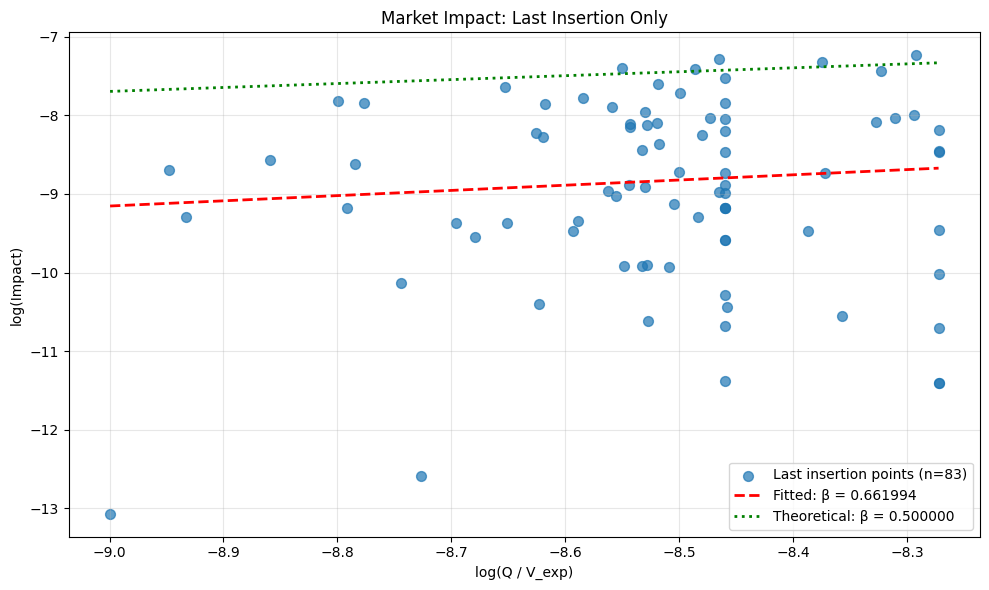

Alpha (fixed intercept): -3.195274
Fitted Beta: 0.661994
Theoretical Beta: 0.500000
Number of valid points: 83


In [19]:
# Create a simple plot showing only the last insertion with theoretical and fitted betas
import matplotlib.pyplot as plt

# Filter points_df to only include the last insertion for each sample
last_insertion_df = points_df.groupby('sample_id').tail(1).reset_index(drop=True)

# Calculate the fitted beta using the same method as in the dashboard
alpha_global = float(coeffs_df["alpha_hat"].mean(skipna=True)) if not coeffs_df.empty else 0.0
X = last_insertion_df["x"].to_numpy()
Y = last_insertion_df["y"].to_numpy()

# Filter out invalid points
valid_mask = np.isfinite(X) & np.isfinite(Y) & (X != 0)
x_valid = X[valid_mask]
y_valid = Y[valid_mask]

# Calculate fitted beta
if len(x_valid) >= 2:
    beta_fitted = beta_fit(x_valid, y_valid, alpha_global, method=est_method)
else:
    beta_fitted = np.nan

# Create the plot
plt.figure(figsize=(10, 6))

# Scatter plot of the last insertion points
plt.scatter(X, Y, alpha=0.7, s=50, label=f'Last insertion points (n={len(X)})')

# Plot fitted line
if np.isfinite(beta_fitted) and len(x_valid) >= 2:
    x_range = np.linspace(X.min(), X.max(), 100)
    y_fitted = alpha_global + beta_fitted * x_range
    plt.plot(x_range, y_fitted, 'r--', linewidth=2, 
             label=f'Fitted: β = {beta_fitted:.6f}')

# Plot theoretical line
beta_theory = 0.5
y_theory = alpha_global + beta_theory * x_range
plt.plot(x_range, y_theory, 'g:', linewidth=2, 
         label=f'Theoretical: β = {beta_theory:.6f}')

plt.xlabel('log(Q / V_exp)')
plt.ylabel('log(Impact)')
plt.title('Market Impact: Last Insertion Only')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Alpha (fixed intercept): {alpha_global:.6f}")
print(f"Fitted Beta: {beta_fitted:.6f}")
print(f"Theoretical Beta: {beta_theory:.6f}")
print(f"Number of valid points: {len(x_valid)}")


Available columns in points_df: ['sample_id', 'insertion', 'x', 'y']
Using sample-based analysis instead...


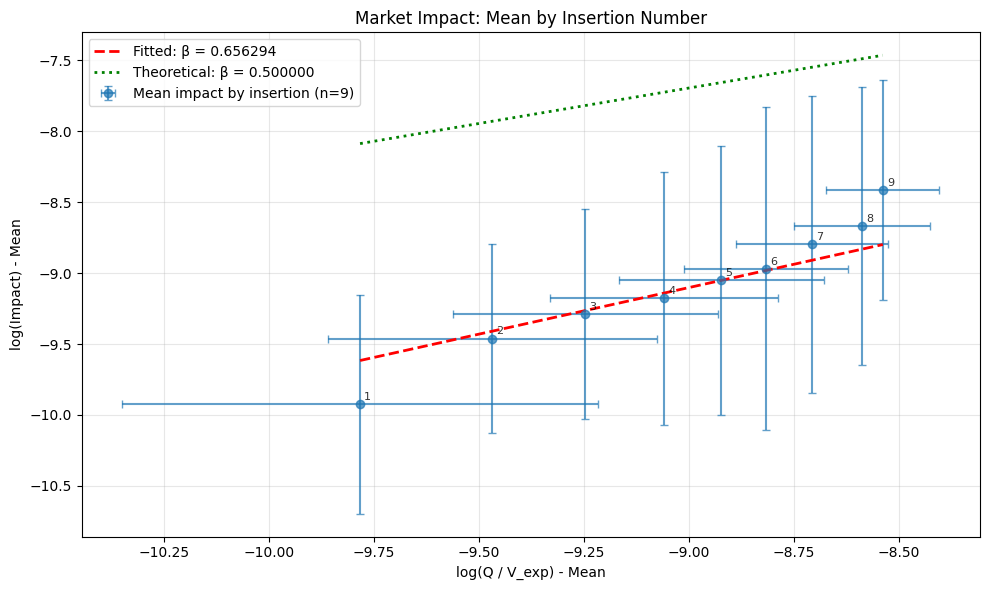

Number of insertions analyzed: 9
Alpha (fixed intercept): -3.195274
Fitted Beta (insertion means): 0.656294
Theoretical Beta: 0.500000
Maximum insertion number: 9


In [20]:
# Calculate mean and std for each insertion across all samples
insertion_stats = []

# First, let's check what columns are available in points_df
print("Available columns in points_df:", points_df.columns.tolist())

# Check if we have insertion_number column, if not, we'll need to create it or use a different approach
if 'insertion_number' not in points_df.columns:
    print("Warning: 'insertion_number' column not found in points_df")
    print("Using sample-based analysis instead...")
    
    # Group by sample_id and create insertion numbers based on order
    points_df_with_insertion = points_df.copy()
    points_df_with_insertion['insertion_number'] = points_df_with_insertion.groupby('sample_id').cumcount() + 1
    max_insertions = points_df_with_insertion['insertion_number'].max()
else:
    points_df_with_insertion = points_df
    max_insertions = points_df['insertion_number'].max()

for insertion_num in range(1, max_insertions + 1):
    # Get data for this insertion number
    insertion_data = points_df_with_insertion[points_df_with_insertion['insertion_number'] == insertion_num]
    
    if len(insertion_data) > 0:
        x_values = insertion_data['x'].to_numpy()
        y_values = insertion_data['y'].to_numpy()
        
        # Filter out invalid points
        valid_mask = np.isfinite(x_values) & np.isfinite(y_values) & (x_values != 0)
        x_valid = x_values[valid_mask]
        y_valid = y_values[valid_mask]
        
        if len(x_valid) > 0:
            x_mean = np.mean(x_valid)
            x_std = np.std(x_valid)
            y_mean = np.mean(y_valid)
            y_std = np.std(y_valid)
            
            insertion_stats.append({
                'insertion_number': insertion_num,
                'x_mean': x_mean,
                'x_std': x_std,
                'y_mean': y_mean,
                'y_std': y_std,
                'n_points': len(x_valid)
            })

# Convert to DataFrame for easier handling
stats_df = pd.DataFrame(insertion_stats)

if len(stats_df) > 0:
    # Create the plot
    plt.figure(figsize=(10, 6))

    # Scatter plot with error bars
    plt.errorbar(stats_df['x_mean'], stats_df['y_mean'], 
                 xerr=stats_df['x_std'], yerr=stats_df['y_std'],
                 fmt='o', alpha=0.7, capsize=3, capthick=1,
                 label=f'Mean impact by insertion (n={len(stats_df)})')

    # Add insertion numbers as text labels
    for i, row in stats_df.iterrows():
        plt.annotate(str(int(row['insertion_number'])), 
                    (row['x_mean'], row['y_mean']),
                    xytext=(3, 3), textcoords='offset points',
                    fontsize=8, alpha=0.8)

    # Add fitted line if we have enough points
    if len(stats_df) >= 2:
        x_mean_valid = stats_df['x_mean'].to_numpy()
        y_mean_valid = stats_df['y_mean'].to_numpy()
        
        # Fit line to mean values
        beta_insertion = beta_fit(x_mean_valid, y_mean_valid, alpha_global, method=est_method)
        
        if np.isfinite(beta_insertion):
            x_range = np.linspace(x_mean_valid.min(), x_mean_valid.max(), 100)
            y_fitted = alpha_global + beta_insertion * x_range
            plt.plot(x_range, y_fitted, 'r--', linewidth=2, 
                     label=f'Fitted: β = {beta_insertion:.6f}')

    # Add theoretical line
    beta_theory = 0.5
    x_range_theory = np.linspace(stats_df['x_mean'].min(), stats_df['x_mean'].max(), 100)
    y_theory = alpha_global + beta_theory * x_range_theory
    plt.plot(x_range_theory, y_theory, 'g:', linewidth=2, 
             label=f'Theoretical: β = {beta_theory:.6f}')

    plt.xlabel('log(Q / V_exp) - Mean')
    plt.ylabel('log(Impact) - Mean')
    plt.title('Market Impact: Mean by Insertion Number')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print(f"Number of insertions analyzed: {len(stats_df)}")
    print(f"Alpha (fixed intercept): {alpha_global:.6f}")
    if len(stats_df) >= 2 and 'beta_insertion' in locals() and np.isfinite(beta_insertion):
        print(f"Fitted Beta (insertion means): {beta_insertion:.6f}")
    print(f"Theoretical Beta: {beta_theory:.6f}")
    print(f"Maximum insertion number: {max_insertions}")
else:
    print("No valid insertion data found for analysis")


# Super debug

In [21]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# ================= CONFIG =================
DEBUG = True
MAX_IDS_TO_PRINT = 30
START_PREFIX_AT = 1
PREFIX_MODE = "le"         # "lt" -> insertion < a, "le" -> insertion <= a

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 50)

# ================ HELPERS ================
def _safe_col(points_df, preferred, fallbacks):
    if preferred in points_df.columns:
        return preferred
    for c in fallbacks:
        if c in points_df.columns:
            return c
    return None

def _safe_num(v, n=6):
    try:
        return float(np.round(v, n))
    except Exception:
        return v

def _print_section(h):
    print("\n" + "="*24 + f" {h} " + "="*24)

def _format_counts(mapping):
    items = [f"{{{int(k)}: {int(mapping[k])}}}" for k in sorted(mapping.keys())]
    return ", ".join(items) + "."

def _format_pairs_inline(series_like):
    pairs = [f"{int(k)}:{int(series_like.loc[k])}" for k in sorted(series_like.index)]
    return ", ".join(pairs) + "."

def debug_points_df(points_df, tag=""):
    _print_section(f"[DEBUG] points_df summary {tag}")
    if points_df is None:
        print("points_df is None")
        return
    print(f"shape: {points_df.shape}")
    cols = list(points_df.columns)
    print(f"columns[{len(cols)}]: {cols}")
    if len(points_df) == 0:
        print("points_df is EMPTY.")
        return
    with pd.option_context('display.max_columns', None, 'display.width', 200):
        print("head(5):")
        print(points_df.head(5))
        print("tail(5):")
        print(points_df.tail(5))
    col_i = _safe_col(points_df, "insertion", ["ins_idx", "insertion_idx", "idx"])
    if col_i:
        ii = pd.to_numeric(points_df[col_i], errors="coerce").dropna().astype(int)
        if len(ii):
            print(f"insertion: min={ii.min()}, max={ii.max()}, unique_count={ii.nunique()}, total={len(ii)}")
            cnt_by_ins = ii.value_counts().sort_index()
            print("insertion counts: " + _format_pairs_inline(cnt_by_ins))
    if "sample_id" in points_df.columns:
        sid = points_df["sample_id"].dropna()
        print(f"sample_id: unique={sid.nunique()}, total_rows_with_id={sid.shape[0]}")

def identity_checks(cnt_by_ins, counts_tail, counts_pref, ins_min, ins_max, total_points):
    _print_section("IDENTITY CHECKS")
    print("[A-DEBUG] points used per a for [a:]:")
    print(_format_counts(counts_tail))
    print("[A-DEBUG] points used per a for [:a]:")
    print(_format_counts(counts_pref))
    if PREFIX_MODE == "le":
        mismatches = []
        for a in range(ins_min, ins_max + 1):
            t_next = counts_tail.get(a + 1, 0) if (a + 1) <= ins_max else 0
            p_inc = counts_pref.get(a, 0)
            if t_next + p_inc != total_points:
                mismatches.append((a, t_next, p_inc))
        if mismatches:
            print("[CHECK] MISMATCHES:", mismatches)
        p_max = counts_pref.get(ins_max, 0)
        print(f"[DEMO] [:max] == total?  prefix[{ins_max}]={p_max}, total={total_points}, equal={p_max == total_points}")

# ================== CORE: replicate dashboard compute logic (no plotting) ==================
def _compute_points_and_coeffs_like_dashboard(
    b_dict_local, m_dict_local, *, hist_steps, gen_block, num_insertions, tick_size=100
):
    """
    Reproduces the x/y and per-sample alpha/beta from market_impact_dashboard_from_raw,
    including use of sample_day_map (H, L, execution_sum) and fixed-intercept per-sample beta.
    Returns points_df (sample_id, insertion, x, y) and coeffs_df (alpha_hat, beta_hat).
    """
    EVENT_TYPE_COL = 1
    PRICE_COL      = 3
    SIZE_COL       = 5
    eps = 1e-12
    tol = 1e-12

    sample_ids = sorted(set(b_dict_local.keys()) & set(m_dict_local.keys()))
    rows_points = []
    coeff_rows = []

    for sid in sample_ids:
        messages_ticks = m_dict_local[sid]
        book = b_dict_local[sid]  # not used, but kept for parity
        T = len(messages_ticks)

        # insertion schedule (same)
        insertion_positions = hist_steps + np.arange(1, num_insertions + 1) * gen_block
        valid_insertions = [pos for pos in insertion_positions if pos < T]
        if not valid_insertions:
            coeff_rows.append({"sample_id": sid, "alpha_hat": np.nan, "beta_hat": np.nan, "n_used": 0, "n_total": 0})
            continue

        # Reference price at first insertion (ticks -> $)
        ref_idx = valid_insertions[0]
        reference_price = float(messages_ticks[ref_idx, PRICE_COL]) / tick_size

        # ---- NEW: read H, L, execution_sum from sample_day_map (fallbacks identical to dashboard) ----
        try:
            day_row = sample_day_map[sample_day_map['sample_id'] == sid]
            if not day_row.empty:
                H_ticks = float(day_row.iloc[0]['highest_price'])
                L_ticks = float(day_row.iloc[0]['lowest_price'])
                execution_sum = float(day_row.iloc[0]['execution_sum'])
            else:
                H_ticks = float(np.max(messages_ticks[:hist_steps, PRICE_COL])) if hist_steps <= T else float(np.max(messages_ticks[:, PRICE_COL]))
                L_ticks = float(np.min(messages_ticks[:hist_steps, PRICE_COL])) if hist_steps <= T else float(np.min(messages_ticks[:, PRICE_COL]))
                exec_mask = (messages_ticks[:, EVENT_TYPE_COL].astype(int) == 4)
                execution_sum = float(np.sum(messages_ticks[exec_mask, SIZE_COL].astype(float)))
        except Exception:
            H_ticks = float(np.max(messages_ticks[:hist_steps, PRICE_COL])) if hist_steps <= T else float(np.max(messages_ticks[:, PRICE_COL]))
            L_ticks = float(np.min(messages_ticks[:hist_steps, PRICE_COL])) if hist_steps <= T else float(np.min(messages_ticks[:, PRICE_COL]))
            exec_mask = (messages_ticks[:, EVENT_TYPE_COL].astype(int) == 4)
            execution_sum = float(np.sum(messages_ticks[exec_mask, SIZE_COL].astype(float)))

        # Convert to dollars for Parkinson eta
        H = float(H_ticks) / tick_size
        L = float(L_ticks) / tick_size
        if np.isfinite(H) and np.isfinite(L) and H > L and L > 0:
            eta_day = np.log(H / L) / 0.8325546
            alpha_fixed = float(np.log(max(eta_day, eps)))   # α = ln(η)
        else:
            eta_day = eps
            alpha_fixed = float(np.log(eta_day))

        # Convert messages to dollars for helper functions
        messages_dollars = messages_ticks.astype(float).copy()
        messages_dollars[:, PRICE_COL] /= tick_size

        # ---- Use your helper functions exactly like in dashboard ----
        impact, vwap_series, Q_cum, log_imp = calculate_impact(
            messages_dollars, valid_insertions, reference_price
        )
        V_exp, log_qv = calculate_market_volume(
            messages_dollars, hist_steps, valid_insertions, execution_sum
        )

        # Collect per-insertion points
        mask_zero = impact <= tol
        mask_pos  = ~mask_zero
        used_x = []
        used_y = []
        for j, _idx in enumerate(valid_insertions):
            if mask_zero[j] or (not np.isfinite(log_qv[j])) or (not np.isfinite(log_imp[j])):
                continue
            rows_points.append({
                "sample_id": sid,
                "insertion": int(j + 1),
                "x": float(log_qv[j]),   # log(Q / V_exp) with V_exp from sample_day_map
                "y": float(log_imp[j])   # log(Impact)
            })
            used_x.append(log_qv[j])
            used_y.append(log_imp[j])

        used_x = np.asarray(used_x, dtype=float)
        used_y = np.asarray(used_y, dtype=float)
        n_used = int(np.sum(np.isfinite(used_x) & np.isfinite(used_y) & (used_x != 0)))
        n_total = int(len(valid_insertions))

        # per-sample β with fixed intercept using beta_fit function
        if n_used >= 2:
            valid_mask = np.isfinite(used_x) & np.isfinite(used_y) & (used_x != 0)
            if np.sum(valid_mask) >= 2:
                beta_hat = beta_fit(used_x[valid_mask], used_y[valid_mask], alpha_fixed, method=est_method)
            else:
                beta_hat = np.nan
        else:
            beta_hat = np.nan

        coeff_rows.append({
            "sample_id": sid,
            "alpha_hat": alpha_fixed,   # fixed ln(η_day)
            "beta_hat": beta_hat,
            "n_used": n_used,
            "n_total": n_total,
        })

    points_df = pd.DataFrame(rows_points)
    coeffs_df = pd.DataFrame.from_records(coeff_rows).set_index("sample_id").sort_index()
    return points_df, coeffs_df

# ================= MAIN (now uses new x/y and fixed-intercept slope) =================
cutoffs = [0.0, 0.2, 0.4, 0.6, 0.8]
filtered_sample_numbers = {}
fig = go.Figure()

for vcut in cutoffs:
    # Your existing filtering util (unchanged)
    x_filt, all_series_filt, merged_filt, hist_steps_filt, gen_block_filt = prepare_volatility_filtered_series(
        merged, hist_msgs, n_gen_msgs, midprice_step_size, volatility_cutoff=vcut
    )
    sample_ids = list(merged_filt['id'])
    filtered_sample_numbers[vcut] = sample_ids
    print(f"Cutoff {vcut}: {len(sample_ids)} samples")
    if DEBUG:
        ids_preview = sample_ids[:MAX_IDS_TO_PRINT]
        print(f"Sample IDs: {ids_preview}{' ...' if len(sample_ids) > MAX_IDS_TO_PRINT else ''}")

    # Filter your dicts
    b_dict_filt = {k: b_dict[k] for k in sample_ids if k in b_dict}
    m_dict_filt = {k: m_dict[k] for k in sample_ids if k in m_dict}

    # === NEW: compute points & coeffs with the exact same logic as the dashboard ===
    points_df, coeffs_df = _compute_points_and_coeffs_like_dashboard(
        b_dict_filt, m_dict_filt,
        hist_steps=hist_steps, gen_block=gen_block, num_insertions=num_insertions, tick_size=100
    )

    if DEBUG:
        debug_points_df(points_df, tag=f"(cutoff={vcut})")
    if points_df is None or len(points_df) == 0:
        continue

    # Column mapping
    COL_INS = "insertion" if "insertion" in points_df.columns else _safe_col(points_df, "insertion", ["ins_idx", "idx"])
    COL_X = "x" if "x" in points_df.columns else _safe_col(points_df, "x", ["log_qv"])
    COL_Y = "y" if "y" in points_df.columns else _safe_col(points_df, "y", ["log_impact"])

    ins_series = pd.to_numeric(points_df[COL_INS], errors="coerce").dropna().astype(int)
    ins_min, ins_max = int(ins_series.min()), int(ins_series.max())
    cnt_by_ins = ins_series.value_counts().sort_index()
    total_points = int(ins_series.shape[0])

    # === FIXED-INTERCEPT FIT: use α_global = mean(alpha_hat) exactly like the dashboard ===
    alpha_global = float(coeffs_df["alpha_hat"].mean(skipna=True)) if not coeffs_df.empty else 0.0

    def _fixed_intercept_beta(sub_df):
        """
        Compute beta with fixed intercept using beta_fit function
        (matching your dashboard's fit_for_mask logic)
        """
        if sub_df is None or len(sub_df) < 2:
            return np.nan
        X = pd.to_numeric(sub_df[COL_X], errors="coerce").to_numpy(dtype=float)
        Y = pd.to_numeric(sub_df[COL_Y], errors="coerce").to_numpy(dtype=float)
        valid = np.isfinite(X) & np.isfinite(Y) & (X != 0)
        if np.sum(valid) < 2:
            return np.nan
        return beta_fit(X[valid], Y[valid], alpha_global, method=est_method)

    # Tail [a:]
    a_tail = list(range(ins_min, ins_max + 1))
    betas_tail, counts_tail = [], {}
    for a in a_tail:
        sub = points_df[points_df[COL_INS] >= a]
        counts_tail[a] = len(sub)
        betas_tail.append(_fixed_intercept_beta(sub))

    # Prefix [:a] (<= or < depending on PREFIX_MODE)
    a_pref = list(range(max(START_PREFIX_AT, 1), ins_max + 1))
    betas_pref, counts_pref = [], {}
    for a in a_pref:
        sub = points_df[points_df[COL_INS] <= a] if PREFIX_MODE == "le" else points_df[points_df[COL_INS] < a]
        counts_pref[a] = len(sub)
        betas_pref.append(_fixed_intercept_beta(sub))

    # Exact-at-a
    a_exact = list(range(ins_min, ins_max + 1))
    betas_exact, counts_exact = [], {}
    for a in a_exact:
        sub = points_df[points_df[COL_INS] == a]
        counts_exact[a] = len(sub)
        betas_exact.append(_fixed_intercept_beta(sub))

    identity_checks(cnt_by_ins, counts_tail, counts_pref, ins_min, ins_max, total_points)

    # Plot with legend labels including cutoff
    fig.add_trace(go.Scatter(
        x=a_tail, y=betas_tail, mode="lines+markers",
        name=f"Vol:{vcut} [a:] (tail)"
    ))
    fig.add_trace(go.Scatter(
        x=a_pref, y=betas_pref, mode="lines+markers",
        name=f"Vol:{vcut} [:a] (prefix)"
    ))
    fig.add_trace(go.Scatter(
        x=a_exact, y=betas_exact, mode="lines+markers",
        name=f"Vol:{vcut} [exact @ a]"
    ))

# Guides
if len(fig.data) > 0:
    all_x = np.concatenate([np.asarray(tr.x, dtype=float) for tr in fig.data if len(tr.x)])
    x_min, x_max = int(np.nanmin(all_x)), int(np.nanmax(all_x))
else:
    x_min, x_max = 1, 20
fig.add_trace(go.Scatter(x=[x_min, x_max], y=[0.5, 0.5], mode="lines", line=dict(dash="dash"), name="y = 0.5"))
fig.add_trace(go.Scatter(x=[x_min, x_max], y=[0, 0], mode="lines", name="y = 0"))

fig.update_xaxes(title_text="a (insertion index threshold)", dtick=1)
fig.update_yaxes(title_text="β (slope)")
fig.update_layout(
    title=f"Global β vs a — tail, prefix, exact (PREFIX_MODE='{PREFIX_MODE}', method='{est_method}')",
    template="plotly_white", width=980, height=560
)
fig.show()

Before filtering: 89 samples

After filtering: 89 samples

Cutoff 0.0: 89 samples
Sample IDs: [37, 256, 257, 373, 441, 486, 512, 545, 557, 585, 819, 844, 850, 972, 1004, 1034, 1074, 1102, 1123, 1151, 1176, 1219, 1232, 1239, 1296, 1340, 1448, 1548, 1555, 1579] ...

======================== [DEBUG] points_df summary (cutoff=0.0) ========================
shape: (629, 4)
columns[4]: ['sample_id', 'insertion', 'x', 'y']
head(5):
   sample_id  insertion         x          y
0        256          3 -9.985687 -11.594231
1        256          4 -9.607167  -9.443951
2        256          5 -9.333234  -9.065430
3        256          6 -9.118432  -8.888708
4        256          7 -9.063280  -8.853076
tail(5):
     sample_id  insertion         x         y
624       6177          6 -8.783026 -8.692042
625       6177          7 -8.628875 -8.558511
626       6177          8 -8.495344 -8.343736
627       6177          9 -8.377561 -8.159238
628       6177         10 -8.293764 -8.001169
insertion: min=2,

In [22]:
# ================= SAMPLE SIZE ANALYSIS (tail [a:] only) =================
sample_sizes = [100, 200, 300, 400, "all"]
fig2 = go.Figure()

# Get all sample IDs (no volatility filtering)
all_sample_ids = list(merged['id'])
print(f"Total available samples: {len(all_sample_ids)}")

for sample_limit in sample_sizes:
    if sample_limit == "all":
        current_sample_ids = all_sample_ids
        label_suffix = f"n={len(current_sample_ids)}"
    else:
        current_sample_ids = all_sample_ids[:sample_limit]
        label_suffix = f"n={sample_limit}"
    
    print(f"Processing {label_suffix}")
    
    # Filter your dicts
    b_dict_filt = {k: b_dict[k] for k in current_sample_ids if k in b_dict}
    m_dict_filt = {k: m_dict[k] for k in current_sample_ids if k in m_dict}
    
    # Compute points & coeffs
    points_df, coeffs_df = _compute_points_and_coeffs_like_dashboard(
        b_dict_filt, m_dict_filt,
        hist_steps=hist_steps, gen_block=gen_block, num_insertions=num_insertions, tick_size=100
    )
    
    if DEBUG:
        debug_points_df(points_df, tag=f"({label_suffix})")
    if points_df is None or len(points_df) == 0:
        continue
    
    # Column mapping
    COL_INS = "insertion" if "insertion" in points_df.columns else _safe_col(points_df, "insertion", ["ins_idx", "idx"])
    COL_X = "x" if "x" in points_df.columns else _safe_col(points_df, "x", ["log_qv"])
    COL_Y = "y" if "y" in points_df.columns else _safe_col(points_df, "y", ["log_impact"])
    
    ins_series = pd.to_numeric(points_df[COL_INS], errors="coerce").dropna().astype(int)
    ins_min, ins_max = int(ins_series.min()), int(ins_series.max())
    
    # Global alpha for fixed-intercept fit
    alpha_global = float(coeffs_df["alpha_hat"].mean(skipna=True)) if not coeffs_df.empty else 0.0
    
    def _fixed_intercept_beta(sub_df):
        """
        Compute beta with fixed intercept using beta_fit function
        """
        if sub_df is None or len(sub_df) < 2:
            return np.nan
        X = pd.to_numeric(sub_df[COL_X], errors="coerce").to_numpy(dtype=float)
        Y = pd.to_numeric(sub_df[COL_Y], errors="coerce").to_numpy(dtype=float)
        valid = np.isfinite(X) & np.isfinite(Y) & (X != 0)
        if np.sum(valid) < 2:
            return np.nan
        beta = beta_fit(X[valid], Y[valid], alpha_global, method=est_method)
        return beta
    
    # Tail [a:] only
    a_tail = list(range(ins_min, ins_max + 1))
    betas_tail = []
    for a in a_tail:
        sub = points_df[points_df[COL_INS] >= a]
        betas_tail.append(_fixed_intercept_beta(sub))
    
    # Plot
    fig2.add_trace(go.Scatter(
        x=a_tail, y=betas_tail, mode="lines+markers",
        name=f"Samples {label_suffix}"
    ))

# Guides for second plot
if len(fig2.data) > 0:
    all_x = np.concatenate([np.asarray(tr.x, dtype=float) for tr in fig2.data if len(tr.x)])
    x_min, x_max = int(np.nanmin(all_x)), int(np.nanmax(all_x))
else:
    x_min, x_max = 1, 20
fig2.add_trace(go.Scatter(x=[x_min, x_max], y=[0.5, 0.5], mode="lines", line=dict(dash="dash"), name="y = 0.5"))
fig2.add_trace(go.Scatter(x=[x_min, x_max], y=[0, 0], mode="lines", name="y = 0"))

fig2.update_xaxes(title_text="a (insertion index threshold)", dtick=1)
fig2.update_yaxes(title_text="β (slope)")
fig2.update_layout(
    title="Global β vs a — Sample Size Analysis [a:] (tail)",
    template="plotly_white", width=980, height=560
)
fig2.show()


Total available samples: 89
Processing n=100

======================== [DEBUG] points_df summary (n=100) ========================
shape: (629, 4)
columns[4]: ['sample_id', 'insertion', 'x', 'y']
head(5):
   sample_id  insertion         x          y
0        256          3 -9.985687 -11.594231
1        256          4 -9.607167  -9.443951
2        256          5 -9.333234  -9.065430
3        256          6 -9.118432  -8.888708
4        256          7 -9.063280  -8.853076
tail(5):
     sample_id  insertion         x         y
624       6177          6 -8.783026 -8.692042
625       6177          7 -8.628875 -8.558511
626       6177          8 -8.495344 -8.343736
627       6177          9 -8.377561 -8.159238
628       6177         10 -8.293764 -8.001169
insertion: min=2, max=10, unique_count=9, total=629
insertion counts: 2:40, 3:63, 4:65, 5:71, 6:73, 7:76, 8:78, 9:80, 10:83.
sample_id: unique=83, total_rows_with_id=629
Processing n=200

======================== [DEBUG] points_df summary (n